In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Environment is ready")

Environment is ready


# Critical Evaluation and Reproduction of Phishing Website Detection by Machine Learning Techniques

## Project Objective

In this notebook, I will reproduce and critically evaluate the selected source: **"Phishing Website Detection by Machine Learning Techniques"**.

The goal is not only to train machine learning models, but also to check whether the original author's claims are supported by the data and experiments.

This notebook follows a documented research structure:

- Before each major action, I explain what I am going to do, how I am going to do it, and why it matters.
- After each major action, I explain what I found, what changed, and what the cybersecurity consequences may be.

# 1. Dataset Loading

I will load the dataset used by the original phishing website detection project.

I will read the CSV file `urldata.csv` from the local `data/raw/` folder using `pandas.read_csv`.

Before reproducing the author's models, I need to verify that the dataset loads correctly and that its structure matches the original source.

If the dataset was changed, filtered, balanced, or already processed before publication, the reported model performance may not represent real-world phishing detection.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

data_path = "../data/raw/urldata.csv"
df = pd.read_csv(data_path)

df.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## What I found

Each row represents a website/domain. The `Domain` column contains the domain name, while the remaining columns are already-extracted phishing-detection features, such as `Have_IP`, `Have_At`, `URL_Length`, `URL_Depth`, `Redirection`, `TinyURL`, `DNS_Record`, `Web_Traffic`, and `Domain_Age`.

The target column appears to be `Label`. Based on the first rows, `0` appears to represent legitimate websites, but this will be verified using the original source and class distribution.

Most feature values are already numerical, mainly binary 0/1 values, with a few discrete numeric features such as `URL_Depth`.

## Consequences

The dataset is not raw URL data only. It is already processed and feature-engineered, meaning that some preprocessing was performed before publication.

This is important for reproducibility because the feature extraction process must be checked in the original repository. If this process is incomplete or difficult to reproduce, then the experiment depends on hidden or unstable preprocessing steps.

From a cybersecurity perspective, the features are meaningful because they represent common phishing indicators, such as suspicious URL structure, redirection, shortened URLs, domain properties, and webpage behavior. However, converting raw URLs into simplified numeric features may also remove useful context.

Therefore, later analysis should check feature extraction transparency, class balance, duplicated domains, and possible feature redundancy.

# 2. Basic Dataset Integrity Check

Inspection of the basic structure of the dataset.

I will check:

- The number of rows and columns
- The column names
- The data types of each column
- The index structure
- The first rows of the dataset

This step helps verify whether the dataset matches the author's description and whether the columns make sense for the phishing detection problem.

It also helps identify whether the dataset appears to be raw or already processed. If the dataset structure does not match the original source, this may indicate that the dataset was modified, filtered, or processed before publication.

In [49]:
# Inspection of the basic structure of the dataset.
# This includes the dataset size, column names, data types, index, and first rows.

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nIndex information:")
print(df.index)

display(df.head())

Dataset shape:
(10000, 18)

Column names:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

Data types:
Domain             str
Have_IP          int64
Have_At          int64
URL_Length       int64
URL_Depth        int64
Redirection      int64
https_Domain     int64
TinyURL          int64
Prefix/Suffix    int64
DNS_Record       int64
Web_Traffic      int64
Domain_Age       int64
Domain_End       int64
iFrame           int64
Mouse_Over       int64
Right_Click      int64
Web_Forwards     int64
Label            int64
dtype: object

Index information:
RangeIndex(start=0, stop=10000, step=1)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## What I found

The dataset contains 10,000 rows and 18 columns.

Each row represents one website/domain sample. `Domain` is the domain string, `Label` is the target variable, and the remaining 16 columns are numerical features related to URL structure, domain properties, redirection, and webpage behavior.

The dataset uses a default `RangeIndex` from 0 to 9,999, so the index does not represent time, URL ID, or collection order.

Most columns are integers, while `Domain` is stored as a string. This confirms that the dataset has already been feature-extracted and numerically encoded.

## Consequences

The dataset size matches the original project description of 10,000 URLs, which supports basic reproducibility at the dataset-size level.

However, since the dataset already contains extracted features, I need to verify whether the original source explains how these features were created.

This matters for reproducibility because the experiment may not be fully reproducible from raw URLs if the feature extraction process is incomplete or unstable.

It also matters for cybersecurity because a real phishing detection system would need to extract these features from live URLs. If feature extraction depends on unavailable or changing external information, real-world performance may be weaker than notebook performance.

Finally, the lack of timestamp or collection order prevents time-based evaluation, which is a limitation because phishing websites change over time.

## Temporal Analysis

The final dataset does not contain timestamps, collection dates, submission times, or any other temporal features. It also uses a default `RangeIndex`, so the index does not represent time or collection order.

Therefore, a time-based train/test split cannot be performed on the final model-training dataset.

This is a limitation for phishing detection because phishing websites change over time, and a realistic evaluation should ideally test whether a model trained on older URLs can detect newer phishing URLs.

Although the raw PhishTank file contains submission and verification timestamps, these fields were not preserved in the final extracted dataset. As a result, the final dataset does not support temporal evaluation.

# 3. Missing Value Analysis

I will check whether the dataset contains missing values.

I will use `df.isnull().sum()` to count missing values in each column and calculate the total number of missing values in the dataset.

Missing values can affect model training and evaluation. Some machine learning models cannot handle missing values directly.

In cybersecurity data, missing values may also be meaningful. For example, missing DNS records, web traffic information, or domain age may indicate suspicious or newly created websites.

Therefore, I need to check whether missing values exist and whether the original author handled them explicitly.

In [50]:
# I will check the number of missing values in each column.

missing_values = df.isnull().sum().sort_values(ascending=False)
total_missing = missing_values.sum()

print("Total missing values in the dataset:", total_missing)

missing_values_df = missing_values.reset_index()
missing_values_df.columns = ["Column", "Missing Values"]

display(missing_values_df)

Total missing values in the dataset: 0


,Column,Missing Values
0,Domain,0
1,Have_IP,0
2,Have_At,0
3,URL_Length,0
4,URL_Depth,0
5,Redirection,0
6,https_Domain,0
7,TinyURL,0
8,Prefix/Suffix,0
9,DNS_Record,0


## What I found

The dataset does not contain any missing values. Every column has `0` missing values, and the total number of missing values in the dataset is `0`.

This means that no imputation, row removal, or missing-value handling is required before model training.

## Consequences

The absence of missing values makes the modeling process simpler because all samples can be used directly.

However, this also raises a reproducibility question. Some features, such as `DNS_Record`, `Web_Traffic`, and `Domain_Age`, may depend on external data sources that can fail or be unavailable. In the final dataset, these cases were already encoded as numeric values rather than left as missing.

From a cybersecurity perspective, this is important because missing or unavailable domain information can itself be meaningful. For example, a newly created phishing domain may have limited traffic data or incomplete domain-age information.

Therefore, although the final dataset has no missing values, I still need to check how the original source converted unavailable information into numerical feature values.

# 4. Feature Extraction and Reproducibility Check

I will check whether the original source explains how the dataset features were created from the raw URLs or websites.

Inspection of the original repository files, especially:

- `README.md`
- `URL Feature Extraction.ipynb`
- `URLFeatureExtraction.py`
- `DataFiles/README.md`

I will look for explanations of each feature, the feature extraction logic, and whether the final dataset `5.urldata.csv` can be reproduced from the raw URL files.

The dataset already contains extracted and encoded features. This means the final CSV is not raw URL data only.

If the original source clearly documents the feature extraction process, then the experiment is more reproducible.

If the feature extraction process is incomplete, hidden, or difficult to rerun, then the model training results may depend on preprocessing steps that are not fully transparent.

In [51]:
from pathlib import Path

# Inspection of the files available in the original source repository.
# Will help me verify whether the feature extraction process is documented.

original_source_path = Path("../external/original-source")

print("Files in original source repository:")
for path in original_source_path.iterdir():
    print("-", path.name)

print("\nFiles in DataFiles folder:")
for path in (original_source_path / "DataFiles").iterdir():
    print("-", path.name)

Files in original source repository:
- .git
- DataFiles
- Phishing Website Detection by Machine Learning Techniques Presentation.pdf
- Phishing Website Detection_Models & Training.ipynb
- README.md
- URL Feature Extraction.ipynb
- URLFeatureExtraction.py
- XGBoostClassifier.pickle.dat

Files in DataFiles folder:
- 1.Benign_list_big_final.csv
- 2.online-valid.csv
- 3.legitimate.csv
- 4.phishing.csv
- 5.urldata.csv
- README.md


In [52]:
# Inspection of the beginning of the original README file.
# Will help me understand how the author describes the problem, dataset, features, and methodology.

readme_path = original_source_path / "README.md"

with open(readme_path, "r", encoding="utf-8") as file:
    readme_lines = file.readlines()

print("Number of lines in README.md:", len(readme_lines))
print("\nFirst 120 lines of README.md:\n")
print("".join(readme_lines[:120]))

Number of lines in README.md: 53

First 120 lines of README.md:

# Phishing Website Detection by Machine Learning Techniques

## Objective
A phishing website is a common social engineering method that mimics trustful uniform resource locators (URLs) and webpages. The objective of this project is to train machine learning models and deep neural nets on the dataset created to predict phishing websites. Both phishing and benign URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measures and compared.

## Data Collection
The set of phishing URLs are collected from opensource service called **PhishTank**. This service provide a set of phishing URLs in multiple formats like csv, json etc. that gets updated hourly. To download the data: https://www.phishtank.com/developer_info.php. From this dataset, 5000 random phishing URLs are collected to train the ML models.

The legitimate UR

## What I found

The README defines the problem as phishing websites that imitate trusted URLs or webpages to deceive users.

The proposed solution is supervised machine learning. The dataset was created from 5,000 phishing URLs from PhishTank and 5,000 legitimate URLs from the University of New Brunswick URL dataset, producing a balanced dataset of 10,000 URLs.

The README states that 17 features were extracted from three groups: address bar features, domain features, and HTML/JavaScript features. The loaded dataset has 18 columns because it also includes the `Label` column.

The author trained several models, including Decision Tree, Random Forest, MLP, XGBoost, Autoencoder, and SVM. The main reported claim is that XGBoost achieved the highest accuracy, 86.4%.

## Consequences

The README supports basic reproducibility because it identifies the data sources, dataset size, feature groups, final dataset file, and models.

However, the dataset is intentionally balanced, which may not reflect real-world phishing detection where phishing websites are usually less common than legitimate websites. Therefore, accuracy alone may be incomplete.

From a cybersecurity perspective, false negatives may expose users to phishing, fraud, or malware, while false positives may block legitimate websites and reduce trust.

The next step is to inspect the feature extraction files and check whether the final dataset can be reproduced from the raw URLs.

In [53]:
# Inspection of the README file inside the DataFiles folder.
# Will help me understand what each dataset file represents.

datafiles_readme_path = original_source_path / "DataFiles" / "README.md"

with open(datafiles_readme_path, "r", encoding="utf-8") as file:
    datafiles_readme_lines = file.readlines()

print("Number of lines in DataFiles/README.md:", len(datafiles_readme_lines))
print("\nContent of DataFiles/README.md:\n")
print("".join(datafiles_readme_lines))

Number of lines in DataFiles/README.md: 13

Content of DataFiles/README.md:

# Data Files

This folder has the raw & extracted datafiles of this project. The description of each file is as follows:

* [1.Benign_list_big_final.csv:](https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques/blob/master/DataFiles/1.Benign_list_big_final.csv) This file has list of legitimate urls. The total count is 35,300. The source of the dataset is University of New Brunswick, https://www.unb.ca/cic/datasets/url-2016.html. 

* [2.online-valid.csv:](https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques/blob/master/DataFiles/2.online-valid.csv) This file is downloaded from the opensource service called PhishTank. This service provide a set of phishing URLs in multiple formats like csv, json etc. that gets updated hourly. To download the latest data: https://www.phishtank.com/developer_info.php.

* [3.legitimate.csv:](https://github.com/shr

In [54]:
# Inspection of the feature extraction Python script.
# Will help me verify whether the dataset features are explicitly created in code.

feature_script_path = original_source_path / "URLFeatureExtraction.py"

with open(feature_script_path, "r", encoding="utf-8") as file:
    feature_script_lines = file.readlines()

print("Number of lines in URLFeatureExtraction.py:", len(feature_script_lines))
print("\nFirst 160 lines of URLFeatureExtraction.py:\n")
print("".join(feature_script_lines[:160]))

Number of lines in URLFeatureExtraction.py: 392

First 160 lines of URLFeatureExtraction.py:

# -*- coding: utf-8 -*-

# importing required packages for this section
from urllib.parse import urlparse,urlencode
import ipaddress
import re

"""#### **3.1.1. Domain of the URL**
Here, we are just extracting the domain present in the URL. This feature doesn't have much significance in the training. May even be dropped while training the model.
"""
'''
# 1.Domain of the URL (Domain) 
def getDomain(url):  
  domain = urlparse(url).netloc
  if re.match(r"^www.",domain):
	       domain = domain.replace("www.","")
  return domain'''

"""#### **3.1.2. IP Address in the URL**

Checks for the presence of IP address in the URL. URLs may have IP address instead of domain name. If an IP address is used as an alternative of the domain name in the URL, we can be sure that someone is trying to steal personal information with this URL.

If the domain part of URL has IP address, the value assigned to this f

## What I found

`DataFiles/README.md` explains the role of each dataset file. The repository includes raw/source files, intermediate feature files, and the final training dataset.

`1.Benign_list_big_final.csv` contains legitimate URLs from the University of New Brunswick dataset, and `2.online-valid.csv` contains phishing URLs from PhishTank. The author randomly selected 5,000 legitimate URLs and 5,000 phishing URLs. Their extracted features are stored in `3.legitimate.csv` and `4.phishing.csv`, and the combined final dataset is `5.urldata.csv`.

The feature extraction script documents and implements several URL-based features, such as `Have_IP`, `Have_At`, `URL_Length`, `URL_Depth`, `Redirection`, `https_Domain`, `TinyURL`, and `Prefix/Suffix`.

This shows that part of the feature engineering process is transparent and implemented in code.

## Consequences

Providing raw/intermediate files and feature extraction code strengthens reproducibility.

However, reproducibility is still limited because the final dataset depends on random sampling. If the exact seed or sampling process is not documented, another researcher may select different URLs and get different results.

Some feature rules are also heuristic. For example, URL length is treated as suspicious based on a fixed threshold, which may not generalize to all modern URLs.

From a cybersecurity perspective, this matters because phishing techniques change over time. Attackers can use shorter URLs, legitimate-looking domains, or avoid obvious suspicious patterns.

Therefore, I still need to inspect the domain-based and HTML/JavaScript-based features, since they may depend on external services, live websites, DNS, WHOIS, or website availability.


In [55]:
# Inspection of the names of the feature extraction functions.
# Will help me verify whether all dataset columns can be traced back to implemented code.

import re

function_names = []

for line in feature_script_lines:
    match = re.match(r"def\s+([a-zA-Z_][a-zA-Z0-9_]*)\(", line)
    if match:
        function_names.append(match.group(1))

print("Feature extraction functions found:")
for function_name in function_names:
    print("-", function_name)

print("\nNumber of functions found:", len(function_names))

Feature extraction functions found:
- getDomain
- havingIP
- haveAtSign
- getLength
- getDepth
- redirection
- httpDomain
- tinyURL
- prefixSuffix
- web_traffic
- domainAge
- domainEnd
- iframe
- mouseOver
- rightClick
- forwarding
- featureExtraction

Number of functions found: 17


In [56]:
# Inspection of the next part of the feature extraction script.
# This section should include domain-based and HTML/JavaScript-based features.

print("Lines 160 to 320 of URLFeatureExtraction.py:\n")
print("".join(feature_script_lines[160:320]))

Lines 160 to 320 of URLFeatureExtraction.py:


Each of these features are explained and the coded below:
"""

#!pip install python-whois

# importing required packages for this section
import re
from bs4 import BeautifulSoup
#import whois
import urllib
import urllib.request
from datetime import datetime

"""#### **3.2.1. DNS Record**

For phishing websites, either the claimed identity is not recognized by the WHOIS database or no records founded for the hostname. 
If the DNS record is empty or not found then, the value assigned to this feature is 1 (phishing) or else 0 (legitimate).
"""

# 11.DNS Record availability (DNS_Record)
# obtained in the featureExtraction function itself

"""#### **3.2.2. Web Traffic**

This feature measures the popularity of the website by determining the number of visitors and the number of pages they visit. However, since phishing websites live for a short period of time, they may not be recognized by the Alexa database (Alexa the Web Information Company., 

## What I found

The feature extraction script contains 17 feature-related functions, matching the README statement that 17 features were extracted.

The script includes URL-based features such as `havingIP`, `haveAtSign`, `getLength`, `getDepth`, `redirection`, `httpDomain`, `tinyURL`, and `prefixSuffix`. These are mostly rule-based and relatively reproducible because they depend mainly on the URL string.

However, other features are less stable. `Web_Traffic`, `Domain_Age`, `Domain_End`, `iFrame`, `Mouse_Over`, `Right_Click`, and `Web_Forwards` depend on external or live information such as traffic services, WHOIS records, HTTP requests, webpage content, and redirect behavior.

## Consequences

The source is partially reproducible because the feature extraction logic is visible and the final CSV can be used directly.

However, reproducing the exact final dataset from raw URLs may be difficult because some feature values can change over time. Phishing websites may disappear, legitimate websites may update their HTML, domain records may change, and external services may return different results.

From a cybersecurity perspective, this matters because phishing websites are temporary and adaptive. A model trained on a fixed extracted dataset may not fully represent performance in a live phishing detection system where features must be extracted from changing websites.


In [57]:
# Inspection of the final part of the feature extraction script.
# This section should include the remaining HTML/JavaScript features and the final featureExtraction function.

print("Lines 320 to the end of URLFeatureExtraction.py:\n")
print("".join(feature_script_lines[320:]))

Lines 320 to the end of URLFeatureExtraction.py:

  if response == "":
    return 1
  else:
    if re.findall(r"event.button ?== ?2", response.text):
      return 0
    else:
      return 1

"""### **3.3.4. Website Forwarding**
The fine line that distinguishes phishing websites from legitimate ones is how many times a website has been redirected. In our dataset, we find that legitimate websites have been redirected one time max. On the other hand, phishing websites containing this feature have been redirected at least 4 times.
"""

# 18.Checks the number of forwardings (Web_Forwards)    
def forwarding(response):
  if response == "":
    return 1
  else:
    if len(response.history) <= 2:
      return 0
    else:
      return 1

"""## **4. Computing URL Features**

Create a list and a function that calls the other functions and stores all the features of the URL in the list. We will extract the features of each URL and append to this list.
"""

#Function to extract features
def feature

## What I found

The function `featureExtraction(url)` combines the individual feature functions into one feature vector. It creates features from three groups: address-bar features, domain-based features, and HTML/JavaScript-based features.

The script also defines the expected final feature names, including `Domain`, `Have_IP`, `Have_At`, `URL_Length`, `URL_Depth`, `Redirection`, `https_Domain`, `TinyURL`, `Prefix/Suffix`, `DNS_Record`, `Web_Traffic`, `Domain_Age`, `Domain_End`, `iFrame`, `Mouse_Over`, `Right_Click`, `Web_Forwards`, and `Label`.

These feature names match the columns in the loaded dataset.

However, I found a reproducibility issue: the script calls `whois.whois(...)`, but the `import whois` line is commented out. Therefore, the script may not run as a standalone Python file without fixing the import or dependencies.

The function also depends on external and time-sensitive information, including WHOIS records, Alexa web traffic, HTTP requests, webpage HTML, and redirect history.

## Consequences

The matching feature names support the claim that the final dataset was created using this extraction process.

However, the full pipeline is only partially reproducible. The logic is visible, but the code may require dependency fixes, and several feature values may change over time because they depend on live websites and external services.

Therefore, the provided `5.urldata.csv` is more reproducible than recreating the dataset from raw URLs.

In the final report, I should distinguish between two reproducibility levels: model-training reproducibility from the provided CSV, and full pipeline reproducibility from raw URLs to extracted features. The first appears feasible, while the second is weaker.

# 5. Pipeline Retraceability Check

I will check whether the final dataset `5.urldata.csv` can be traced back to the earlier files in the original repository.

Inspection of the shape and columns of the following files:

- `1.Benign_list_big_final.csv`
- `2.online-valid.csv`
- `3.legitimate.csv`
- `4.phishing.csv`
- `5.urldata.csv`

Then I will check whether `5.urldata.csv` appears to be the combination of `3.legitimate.csv` and `4.phishing.csv`.

If the final dataset can be reconstructed from the intermediate files, then the model-training dataset is more reproducible.

If the final dataset cannot be matched to the intermediate files, then there may be hidden preprocessing, filtering, row removal, or modification steps that are not fully documented.

In [58]:
# I will load all data files from the original repository and inspect their shapes and columns.

datafiles_path = original_source_path / "DataFiles"

file_paths = {
    "benign_raw": datafiles_path / "1.Benign_list_big_final.csv",
    "phishing_raw": datafiles_path / "2.online-valid.csv",
    "legitimate_features": datafiles_path / "3.legitimate.csv",
    "phishing_features": datafiles_path / "4.phishing.csv",
    "final_dataset": datafiles_path / "5.urldata.csv",
}

dataframes = {}

for name, path in file_paths.items():
    temp_df = pd.read_csv(path)
    dataframes[name] = temp_df
    
    print(f"\n{name}")
    print("Path:", path)
    print("Shape:", temp_df.shape)
    print("Columns:", temp_df.columns.tolist())
    display(temp_df.head())


benign_raw
Path: ..\external\original-source\DataFiles\1.Benign_list_big_final.csv
Shape: (35377, 1)
Columns: ['http://1337x.to/torrent/1048648/American-Sniper-2014-MD-iTALiAN-DVDSCR-X264-BST-MT/']


,http://1337x.to/torrent/1048648/American-Sniper-2014-MD-iTALiAN-DVDSCR-X264-BST-MT/
0,http://1337x.to/torrent/1110018/Blackhat-2015-...
1,http://1337x.to/torrent/1122940/Blackhat-2015-...
2,http://1337x.to/torrent/1124395/Fast-and-Furio...
3,http://1337x.to/torrent/1145504/Avengers-Age-o...
4,http://1337x.to/torrent/1160078/Avengers-age-o...



phishing_raw
Path: ..\external\original-source\DataFiles\2.online-valid.csv
Shape: (14858, 8)
Columns: ['phish_id', 'url', 'phish_detail_url', 'submission_time', 'verified', 'verification_time', 'online', 'target']


,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,6557033,http://u1047531.cp.regruhosting.ru/acces-inges...,http://www.phishtank.com/phish_detail.php?phis...,2020-05-09T22:01:43+00:00,yes,2020-05-09T22:03:07+00:00,yes,Other
1,6557032,http://hoysalacreations.com/wp-content/plugins...,http://www.phishtank.com/phish_detail.php?phis...,2020-05-09T22:01:37+00:00,yes,2020-05-09T22:03:07+00:00,yes,Other
2,6557011,http://www.accsystemprblemhelp.site/checkpoint...,http://www.phishtank.com/phish_detail.php?phis...,2020-05-09T21:54:31+00:00,yes,2020-05-09T21:55:38+00:00,yes,Facebook
3,6557010,http://www.accsystemprblemhelp.site/login_atte...,http://www.phishtank.com/phish_detail.php?phis...,2020-05-09T21:53:48+00:00,yes,2020-05-09T21:54:34+00:00,yes,Facebook
4,6557009,https://firebasestorage.googleapis.com/v0/b/so...,http://www.phishtank.com/phish_detail.php?phis...,2020-05-09T21:49:27+00:00,yes,2020-05-09T21:51:24+00:00,yes,Microsoft



legitimate_features
Path: ..\external\original-source\DataFiles\3.legitimate.csv
Shape: (5000, 18)
Columns: ['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0



phishing_features
Path: ..\external\original-source\DataFiles\4.phishing.csv
Shape: (5000, 18)
Columns: ['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'Tiny_URL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,Tiny_URL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,eevee.tv,0,0,0,4,0,0,0,0,0,1,0,0,0,0,1,0,1
1,appleid.apple.com-sa.pm,0,0,0,1,0,0,0,1,0,1,1,1,0,0,1,0,1
2,grandcup.xyz,0,0,0,0,0,0,0,0,0,1,0,1,1,1,1,1,1
3,villa-azzurro.com,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,1
4,mygpstrip.net,0,0,0,2,0,0,0,0,0,1,0,1,0,0,1,0,1



final_dataset
Path: ..\external\original-source\DataFiles\5.urldata.csv
Shape: (10000, 18)
Columns: ['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


## What I found

The original repository contains raw URL files, intermediate feature files, and the final combined dataset.

The file shapes support the documented dataset construction process:

* `1.Benign_list_big_final.csv`: 35,377 legitimate URL rows
* `2.online-valid.csv`: 14,858 phishing URL records
* `3.legitimate.csv`: 5,000 extracted legitimate samples
* `4.phishing.csv`: 5,000 extracted phishing samples
* `5.urldata.csv`: 10,000 final samples

This supports the claim that the final dataset was created by combining 5,000 legitimate and 5,000 phishing samples.

However, I found two reproducibility details. First, the raw legitimate URL file has no proper header, so it requires loading with `header=None`. Second, the shortened-URL feature is named `TinyURL` in the legitimate feature file but `Tiny_URL` in the phishing feature file, while the final dataset uses `TinyURL`.

## Consequences

The dataset construction process is mostly traceable at the file level.

However, the column-name mismatch suggests that a small cleaning or renaming step was needed before creating the final dataset. If this step is not documented, it is a minor reproducibility weakness.

From a cybersecurity perspective, this does not change the meaning of the feature, but it matters methodologically. Small undocumented preprocessing steps can cause confusion or feature mismatches when reproducing the experiment.

In [59]:
# I will check whether the final dataset is exactly the combination of
# 3.legitimate.csv and 4.phishing.csv.
# Before combining, I will standardize the phishing file column name from Tiny_URL to TinyURL,
# because the final dataset uses TinyURL.

legitimate_features = dataframes["legitimate_features"].copy()
phishing_features = dataframes["phishing_features"].copy()
final_from_repo = dataframes["final_dataset"].copy()

# Standardize column name to match the final dataset
phishing_features = phishing_features.rename(columns={"Tiny_URL": "TinyURL"})

combined_features = pd.concat(
    [legitimate_features, phishing_features],
    ignore_index=True
)

print("Shape of legitimate features:", legitimate_features.shape)
print("Shape of phishing features after renaming:", phishing_features.shape)
print("Shape of combined features:", combined_features.shape)
print("Shape of final dataset:", final_from_repo.shape)

same_shape = combined_features.shape == final_from_repo.shape
same_columns = combined_features.columns.tolist() == final_from_repo.columns.tolist()

print("\nSame shape:", same_shape)
print("Same columns:", same_columns)

if same_shape and same_columns:
    exact_match_same_order = combined_features.equals(final_from_repo)
    print("Exact match in same row order:", exact_match_same_order)
else:
    print("Cannot check exact match because shape or columns differ.")

Shape of legitimate features: (5000, 18)
Shape of phishing features after renaming: (5000, 18)
Shape of combined features: (10000, 18)
Shape of final dataset: (10000, 18)

Same shape: True
Same columns: True
Exact match in same row order: True


## What I found

After renaming `Tiny_URL` to `TinyURL` in `4.phishing.csv`, I combined `3.legitimate.csv` and `4.phishing.csv`.

The combined intermediate dataset has the same shape as the final dataset: 10,000 rows and 18 columns. The column names also match after the renaming step.

The equality check returned `True`, meaning that `5.urldata.csv` is exactly equal to the combined intermediate feature files in the same row order.

## Consequences

This is a strong reproducibility finding. It shows that the final model-training dataset can be exactly reconstructed from `3.legitimate.csv` and `4.phishing.csv`, as long as the column-name inconsistency is handled.

However, this does not prove that the full raw-URL-to-feature pipeline is fully reproducible. The intermediate feature files were already created using feature extraction code, and some features depend on external or time-sensitive sources such as WHOIS records, web traffic rankings, HTTP responses, webpage HTML, and redirect history.

Therefore, reproducibility is strong from intermediate files to `5.urldata.csv`, feasible for model training from the final CSV, but only partial from raw URLs to extracted features.


# 6. Duplicate Analysis

I will check whether the dataset contains duplicated rows, duplicated domains, or repeated feature patterns.

I will check:

1. Fully duplicated rows.
2. Duplicated values in the `Domain` column.
3. Domains that appear with more than one label.
4. Duplicated feature vectors after removing the `Domain` column.

Duplicates can affect the reliability of model evaluation.

If the same row appears more than once, the model may learn repeated examples rather than general phishing patterns.

If the same domain appears multiple times, there may be leakage between the training and test sets, especially if one copy appears in the training set and another copy appears in the test set.

In cybersecurity, this is important because a phishing detection model should generalize to unseen websites, not only recognize websites or feature patterns it has already seen.

In [60]:
# Check for duplicated rows, duplicated domains, and duplicated feature patterns.

full_duplicate_rows = df.duplicated().sum()
duplicated_domains = df["Domain"].duplicated().sum()

print("Number of fully duplicated rows:", full_duplicate_rows)
print("Number of duplicated domains:", duplicated_domains)

# Check whether the same domain appears with more than one label
domain_label_counts = df.groupby("Domain")["Label"].nunique()
domains_with_multiple_labels = domain_label_counts[domain_label_counts > 1]

print("Number of domains with more than one label:", len(domains_with_multiple_labels))

# Check duplicated feature vectors without the Domain column
feature_vector_columns = [col for col in df.columns if col != "Domain"]
duplicated_feature_vectors = df.duplicated(subset=feature_vector_columns).sum()

print("Number of duplicated rows when ignoring Domain:", duplicated_feature_vectors)

# Display examples of duplicated domains, if they exist
duplicated_domain_rows = df[df["Domain"].duplicated(keep=False)].sort_values("Domain")

print("\nExample duplicated domain rows:")
display(duplicated_domain_rows.head(20))

Number of fully duplicated rows: 5626
Number of duplicated domains: 6447
Number of domains with more than one label: 3
Number of duplicated rows when ignoring Domain: 9120

Example duplicated domain rows:


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
9876,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
5746,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8770,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8084,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
8142,03418f6.netsolhost.com,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,0,1
9225,0442d60.wcomhost.com,0,0,0,2,0,0,1,0,0,0,0,1,0,0,1,0,1
9189,0442d60.wcomhost.com,0,0,1,4,0,0,1,0,0,0,0,1,0,0,1,0,1
9314,123formbuilder.com,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1
5054,123formbuilder.com,0,0,1,2,0,0,0,0,0,1,1,0,0,0,1,0,1
2090,1337x.to,0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,0,0


## What I found

The duplicate analysis revealed a major dataset integrity issue.

The dataset contains:

* 5,626 fully duplicated rows
* 6,447 duplicated domain entries
* 3 domains with more than one label
* 9,120 duplicated rows when ignoring the `Domain` column

This means that many samples are repeated either as exact duplicates, repeated domains, or identical feature patterns. The high number of duplicated feature vectors is likely related to the fact that most features are binary or low-cardinality, so different domains can collapse into the same representation.

## Consequences

This is a significant critical-evaluation finding.

If duplicates appear in both the training and test sets, the model may perform well because it has already seen identical or very similar examples during training. This creates a risk of data leakage and may make the reported performance overly optimistic.

From a cybersecurity perspective, this matters because a phishing detector should generalize to new, unseen websites, not only recognize repeated patterns.

The 3 domains with more than one label may indicate labeling inconsistency, reused infrastructure, or loss of path-level URL information.

At this stage, I should not delete duplicates immediately because the first goal is to reproduce and evaluate the original dataset. Later, I can compare the original dataset with a deduplicated version to test how much duplication affects model performance.

In [61]:
# Inspection duplicate counts by label.
# Will help understand whether duplication affects legitimate samples, phishing samples, or both.

duplicate_summary_by_label = (
    df.assign(Is_Full_Duplicate=df.duplicated(keep=False))
      .groupby("Label")["Is_Full_Duplicate"]
      .agg(["sum", "count"])
)

duplicate_summary_by_label["duplicate_percentage"] = (
    duplicate_summary_by_label["sum"] / duplicate_summary_by_label["count"] * 100
)

display(duplicate_summary_by_label)

# Count unique domains by label
unique_domains_by_label = df.groupby("Label")["Domain"].nunique()
total_rows_by_label = df["Label"].value_counts().sort_index()

domain_summary = pd.DataFrame({
    "total_rows": total_rows_by_label,
    "unique_domains": unique_domains_by_label
})

domain_summary["duplicated_domain_rows"] = (
    domain_summary["total_rows"] - domain_summary["unique_domains"]
)

domain_summary["duplicated_domain_percentage"] = (
    domain_summary["duplicated_domain_rows"] / domain_summary["total_rows"] * 100
)

display(domain_summary)

,sum,count,duplicate_percentage
Label,,,
0,4821,5000,96.42
1,1679,5000,33.58


,total_rows,unique_domains,duplicated_domain_rows,duplicated_domain_percentage
Label,,,,
0,5000,246,4754,95.08
1,5000,3310,1690,33.80


In [62]:
# Inspection of domains that appear with more than one label.
# These may indicate label conflicts or loss of URL-level information.

conflicting_domains = domains_with_multiple_labels.index.tolist()

print("Domains with more than one label:")
print(conflicting_domains)

conflicting_domain_rows = df[df["Domain"].isin(conflicting_domains)].sort_values(["Domain", "Label"])
display(conflicting_domain_rows)

Domains with more than one label:
['evernote.com', 'instagram.com', 'twitter.com']


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
565,evernote.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
882,evernote.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
1134,evernote.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
1984,evernote.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
3474,evernote.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812,twitter.com,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
4903,twitter.com,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
4929,twitter.com,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
4962,twitter.com,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0


## What I found

The duplication problem is much stronger in the legitimate class than in the phishing class.

For label `0` legitimate websites, 4,821 out of 5,000 rows are part of duplicated full rows, meaning 96.42% of legitimate samples are involved in duplication. There are also only 246 unique domains out of 5,000 legitimate rows.

For label `1` phishing websites, 1,679 out of 5,000 rows are part of duplicated full rows, meaning 33.58% of phishing samples are involved in duplication. There are 3,310 unique domains out of 5,000 phishing rows.

I also found 3 domains that appear with more than one label: `evernote.com`, `instagram.com`, and `twitter.com`.

## Consequences

This is a major dataset-quality finding.

The legitimate class has much heavier duplication, so the model may learn repeated legitimate-domain patterns instead of general legitimate behavior. If these duplicated rows appear in both train and test sets, test performance may be inflated by duplicate leakage.

The conflicting domains are also important. In cybersecurity, the same trusted platform can appear in both legitimate and phishing contexts because attackers may abuse known platforms, redirects, or URL paths. However, because the dataset stores only the domain and not the full URL, important path-level context may be lost.

Therefore, later model evaluation should compare performance on the original dataset and a deduplicated version to test whether the original results are robust.

In [63]:
# Creation of a deduplicated version of the dataset by removing fully duplicated rows.
# This is only for analysis at this stage. I will not overwrite the original dataset.

df_no_full_duplicates = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Shape after removing full duplicates:", df_no_full_duplicates.shape)
print("Rows removed:", df.shape[0] - df_no_full_duplicates.shape[0])

print("\nClass distribution in original dataset:")
display(df["Label"].value_counts().sort_index())

print("\nClass distribution after removing full duplicates:")
display(df_no_full_duplicates["Label"].value_counts().sort_index())

print("\nClass distribution percentages after removing full duplicates:")
display(
    (df_no_full_duplicates["Label"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

Original dataset shape: (10000, 18)
Shape after removing full duplicates: (4374, 18)
Rows removed: 5626

Class distribution in original dataset:


Label
0    5000
1    5000
Name: count, dtype: int64


Class distribution after removing full duplicates:


Label
0     529
1    3845
Name: count, dtype: int64


Class distribution percentages after removing full duplicates:


Label
0    12.09
1    87.91
Name: proportion, dtype: float64

## What I found

After removing fully duplicated rows, the dataset size decreased from 10,000 rows to 4,374 rows. This means that 5,626 exact duplicate rows were removed.

The original dataset was perfectly balanced, with 5,000 legitimate samples and 5,000 phishing samples.

After deduplication, the class distribution changed significantly:

* 529 legitimate samples
* 3,845 phishing samples

This means the deduplicated dataset contains 12.09% legitimate samples and 87.91% phishing samples.

## Consequences

This is a major dataset-quality finding.

The original 50/50 class balance is strongly affected by duplicate rows. After removing exact duplicates, the dataset becomes highly imbalanced toward phishing samples.

This suggests that the original balance may not represent the number of unique examples in the dataset.

From an evaluation perspective, duplicates can create data leakage if the same rows appear in both the training and test sets, which may inflate accuracy.

From a cybersecurity perspective, this matters because a phishing detector should generalize to new and unseen URLs, not repeated samples.

Therefore, model performance should be evaluated on both the original dataset and the deduplicated version.


# 7. Class Balance Analysis

I will inspect the distribution of the target variable `Label` in both the original dataset and the deduplicated dataset.

I will count the number and percentage of samples in each class.

I will also visualize the class distribution using bar charts.

Class balance affects how model performance should be interpreted.

If the dataset is balanced, accuracy may be easier to interpret. If the dataset is imbalanced, accuracy alone can be misleading, and metrics such as precision, recall, F1-score, and confusion matrix become more important.

In cybersecurity, class imbalance is especially important because phishing detection often involves asymmetric risk. Missing a phishing website can expose users to credential theft or financial loss, while falsely blocking a legitimate website can damage trust and usability.

In [64]:
# Comparison of the class distribution in the original dataset and the deduplicated dataset.

class_distribution_original = df["Label"].value_counts().sort_index()
class_distribution_deduplicated = df_no_full_duplicates["Label"].value_counts().sort_index()

class_distribution_summary = pd.DataFrame({
    "original_count": class_distribution_original,
    "original_percentage": (class_distribution_original / len(df) * 100).round(2),
    "deduplicated_count": class_distribution_deduplicated,
    "deduplicated_percentage": (class_distribution_deduplicated / len(df_no_full_duplicates) * 100).round(2)
})

display(class_distribution_summary)

,original_count,original_percentage,deduplicated_count,deduplicated_percentage
Label,,,,
0,5000,50.0,529,12.09
1,5000,50.0,3845,87.91


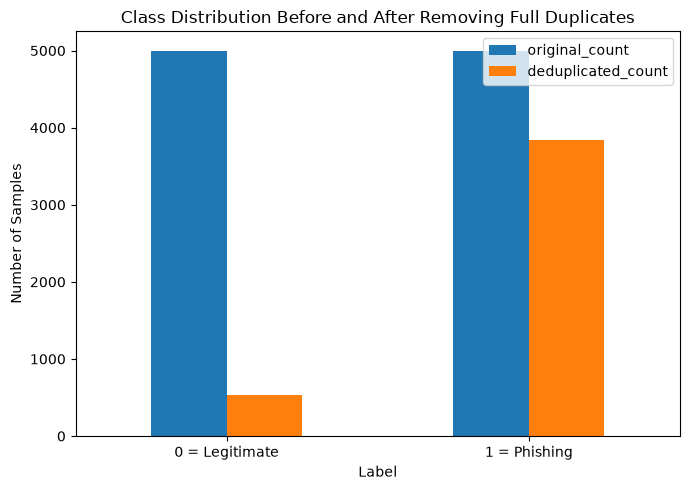

In [65]:
# Visualization of the class distribution before and after removing full duplicates.

fig, ax = plt.subplots(figsize=(7, 5))

class_distribution_summary[["original_count", "deduplicated_count"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Class Distribution Before and After Removing Full Duplicates")
ax.set_xlabel("Label")
ax.set_ylabel("Number of Samples")
ax.set_xticklabels(["0 = Legitimate", "1 = Phishing"], rotation=0)

plt.tight_layout()
plt.show()

## What I found

The original dataset is perfectly balanced:

* 5,000 legitimate samples, 50%
* 5,000 phishing samples, 50%

After removing fully duplicated rows, the class distribution changes significantly:

* 529 legitimate samples, 12.09%
* 3,845 phishing samples, 87.91%

The bar chart shows that most removed duplicate rows came from the legitimate class.

## Consequences

The original dataset appears balanced, but this balance is strongly affected by duplicated legitimate rows.

After deduplication, the dataset becomes highly imbalanced toward phishing samples. This suggests that the original 50/50 balance does not reflect the number of unique examples in each class.

From an evaluation perspective, duplicate rows may inflate accuracy if they appear in both the training and test sets.

From a cybersecurity perspective, the model should generalize to new phishing websites, not repeated samples.

Therefore, model performance should be compared on both the original and deduplicated datasets, using metrics beyond accuracy such as precision, recall, F1-score, and confusion matrix.


# 8. Feature Value Overview

I will inspect the values of each feature column.

I will check the unique values in each feature and count how many different values each feature contains.

Most features in this dataset are handcrafted binary or low-cardinality features. Before modeling, I need to understand whether the features contain meaningful variation or whether some features are almost constant.

Features with very little variation may have limited predictive value. In cybersecurity datasets, this can happen when feature extraction rules are too simple or when many websites receive the same default value because external information was unavailable.

In [66]:
# Inspection of the number of unique values in each column.

feature_columns = [col for col in df.columns if col not in ["Domain", "Label"]]

unique_value_summary = []

for col in feature_columns:
    unique_values = sorted(df[col].dropna().unique())
    unique_value_summary.append({
        "feature": col,
        "num_unique_values": df[col].nunique(),
        "unique_values": unique_values
    })

unique_value_summary_df = pd.DataFrame(unique_value_summary)
display(unique_value_summary_df)

,feature,num_unique_values,unique_values
0,Have_IP,2,"[0, 1]"
1,Have_At,2,"[0, 1]"
2,URL_Length,2,"[0, 1]"
3,URL_Depth,18,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,Redirection,2,"[0, 1]"
5,https_Domain,2,"[0, 1]"
6,TinyURL,2,"[0, 1]"
7,Prefix/Suffix,2,"[0, 1]"
8,DNS_Record,2,"[0, 1]"
9,Web_Traffic,2,"[0, 1]"


In [67]:
# Inspection of the mean value of each feature by label.
# For binary features, the mean represents the percentage of rows where the feature equals 1.

feature_means_by_label = df.groupby("Label")[feature_columns].mean().T
feature_means_by_label.columns = ["Legitimate_mean", "Phishing_mean"]

feature_means_by_label["absolute_difference"] = (
    feature_means_by_label["Phishing_mean"] - feature_means_by_label["Legitimate_mean"]
).abs()

feature_means_by_label = feature_means_by_label.sort_values(
    "absolute_difference",
    ascending=False
)

display(feature_means_by_label)

,Legitimate_mean,Phishing_mean,absolute_difference
URL_Depth,3.3268,2.8172,0.5096
URL_Length,1.0000,0.5468,0.4532
Prefix/Suffix,0.0052,0.1812,0.1760
Domain_Age,0.4556,0.3718,0.0838
Web_Traffic,0.8850,0.8064,0.0786
iFrame,0.0626,0.1192,0.0566
Domain_End,0.8368,0.7830,0.0538
TinyURL,0.0694,0.1112,0.0418
Have_At,0.0050,0.0402,0.0352
Mouse_Over,0.0538,0.0794,0.0256


## What I found

Most features in the dataset are binary, with values `0` and `1`.

The only feature with more than two values is `URL_Depth`, which has 18 unique values and represents the depth of the URL path.

This means the dataset is mostly based on low-cardinality handcrafted features.

The features with the largest differences between legitimate and phishing samples are:

* `URL_Depth`
* `URL_Length`
* `Prefix/Suffix`
* `Domain_Age`
* `Web_Traffic`

Some features show almost no difference between the classes, such as `https_Domain`, `Redirection`, `Right_Click`, and `DNS_Record`. `Right_Click` is especially weak because its value is almost always 1 in both classes.

## Consequences

The low-cardinality feature design helps explain why many different domains share identical feature vectors.

From a modeling perspective, these features can be useful, but they may limit the model’s ability to distinguish between websites when many samples have the same feature pattern.

From a cybersecurity perspective, modern phishing websites may avoid simple suspicious indicators, such as `@` symbols, obvious redirections, or strange URL structures. Therefore, these handcrafted features may not be enough for robust real-world detection.

In the modeling stage, I should check whether the model relies mainly on a small number of features, such as `URL_Length`, `URL_Depth`, and `Prefix/Suffix`.

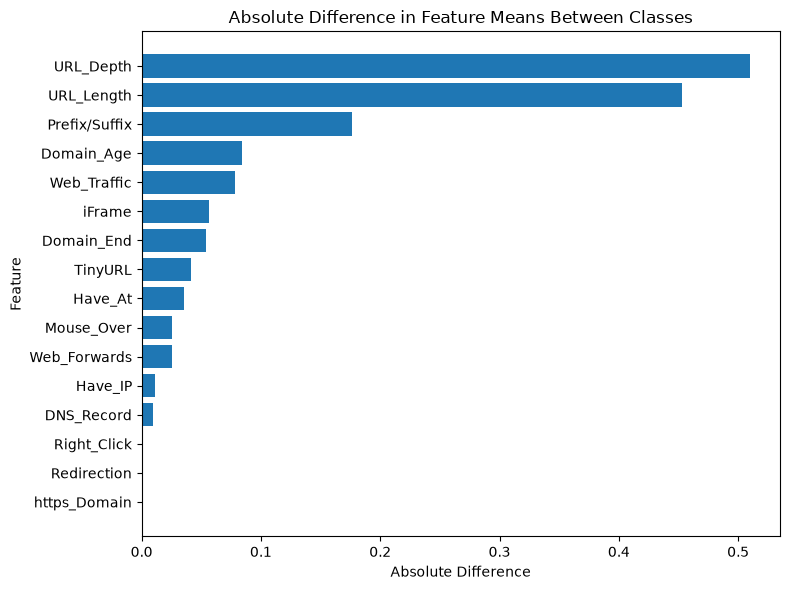

In [68]:
# Visualization of the absolute difference between legitimate and phishing feature means.
# Will help identify which features separate the classes the most.

feature_means_by_label_sorted = feature_means_by_label.sort_values(
    "absolute_difference",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    feature_means_by_label_sorted.index,
    feature_means_by_label_sorted["absolute_difference"]
)

ax.set_title("Absolute Difference in Feature Means Between Classes")
ax.set_xlabel("Absolute Difference")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [69]:
# Comparison of feature means by label in the original dataset and the deduplicated dataset.
# Will help check whether duplicate rows distort the observed feature patterns.

original_feature_means = df.groupby("Label")[feature_columns].mean().T
deduplicated_feature_means = df_no_full_duplicates.groupby("Label")[feature_columns].mean().T

comparison_rows = []

for feature in feature_columns:
    comparison_rows.append({
        "feature": feature,
        "original_legitimate_mean": original_feature_means.loc[feature, 0],
        "deduplicated_legitimate_mean": deduplicated_feature_means.loc[feature, 0],
        "original_phishing_mean": original_feature_means.loc[feature, 1],
        "deduplicated_phishing_mean": deduplicated_feature_means.loc[feature, 1],
    })

feature_mean_comparison = pd.DataFrame(comparison_rows)

feature_mean_comparison["legitimate_mean_change"] = (
    feature_mean_comparison["deduplicated_legitimate_mean"]
    - feature_mean_comparison["original_legitimate_mean"]
).abs()

feature_mean_comparison["phishing_mean_change"] = (
    feature_mean_comparison["deduplicated_phishing_mean"]
    - feature_mean_comparison["original_phishing_mean"]
).abs()

feature_mean_comparison["max_mean_change"] = feature_mean_comparison[
    ["legitimate_mean_change", "phishing_mean_change"]
].max(axis=1)

feature_mean_comparison = feature_mean_comparison.sort_values(
    "max_mean_change",
    ascending=False
)

display(feature_mean_comparison)

,feature,original_legitimate_mean,deduplicated_legitimate_mean,original_phishing_mean,deduplicated_phishing_mean,legitimate_mean_change,phishing_mean_change,max_mean_change
3,URL_Depth,3.3268,3.578450,2.8172,2.573212,0.251650,0.243988,0.251650
10,Domain_Age,0.4556,0.516068,0.3718,0.359948,0.060468,0.011852,0.060468
15,Web_Forwards,0.1180,0.177694,0.0926,0.107672,0.059694,0.015072,0.059694
2,URL_Length,1.0000,1.000000,0.5468,0.492848,0.000000,0.053952,0.053952
9,Web_Traffic,0.8850,0.924386,0.8064,0.795839,0.039386,0.010561,0.039386
4,Redirection,0.0132,0.030246,0.0138,0.014564,0.017046,0.000764,0.017046
13,Mouse_Over,0.0538,0.047259,0.0794,0.094148,0.006541,0.014748,0.014748
11,Domain_End,0.8368,0.822306,0.7830,0.788036,0.014494,0.005036,0.014494
8,DNS_Record,0.0960,0.109641,0.1056,0.103251,0.013641,0.002349,0.013641
6,TinyURL,0.0694,0.079395,0.1112,0.099090,0.009995,0.012110,0.012110


## What I found

The feature difference plot shows that the largest class differences are in:

* `URL_Depth`
* `URL_Length`
* `Prefix/Suffix`
* `Domain_Age`
* `Web_Traffic`

The strongest differences are in `URL_Depth` and `URL_Length`, suggesting that the models may rely heavily on URL-structure features.

The comparison between the original and deduplicated datasets shows that duplicates also affect feature statistics. The biggest change after deduplication appears in `URL_Depth`:

* Original legitimate mean: 3.3268
* Deduplicated legitimate mean: 3.5785
* Original phishing mean: 2.8172
* Deduplicated phishing mean: 2.5732

Other affected features include `Domain_Age`, `Web_Forwards`, `URL_Length`, and `Web_Traffic`.

## Consequences

This strengthens the duplication concern because duplicate rows affect not only class counts but also feature distributions.

From a modeling perspective, `URL_Depth`, `URL_Length`, and `Prefix/Suffix` may become important predictors. However, because these are simple handcrafted features, their robustness should be checked after deduplication.

From a cybersecurity perspective, relying heavily on URL structure may be risky because attackers can adapt by changing URL length, path depth, or domain formatting.
\

# 9. Feature Correlation Analysis

I will inspect correlations between numerical features and the target label.

I will calculate a correlation matrix for all numerical columns, then focus on the correlation between each feature and `Label`.

I will also visualize the correlation matrix using a heatmap.


Correlation analysis helps identify features that are strongly associated with the target and features that may be redundant.

In cybersecurity datasets, correlated handcrafted features may indicate overlapping rules. For example, several URL structure features may capture similar suspicious behavior.

However, correlation does not prove causation. A feature can correlate with phishing in this dataset but still fail to generalize to future phishing attacks.

In [70]:
# Calculation of the correlation between each feature and the target label.

numeric_columns = [col for col in df.columns if col != "Domain"]

correlation_matrix = df[numeric_columns].corr()

label_correlations = (
    correlation_matrix["Label"]
    .drop("Label")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(label_correlations.to_frame(name="correlation_with_label"))

,correlation_with_label
URL_Length,-0.541287
Prefix/Suffix,0.302705
URL_Depth,-0.119707
Have_At,0.118419
Web_Traffic,-0.108793
iFrame,0.098446
Domain_Age,-0.085077
Have_IP,0.074367
TinyURL,0.072921
Domain_End,-0.068556


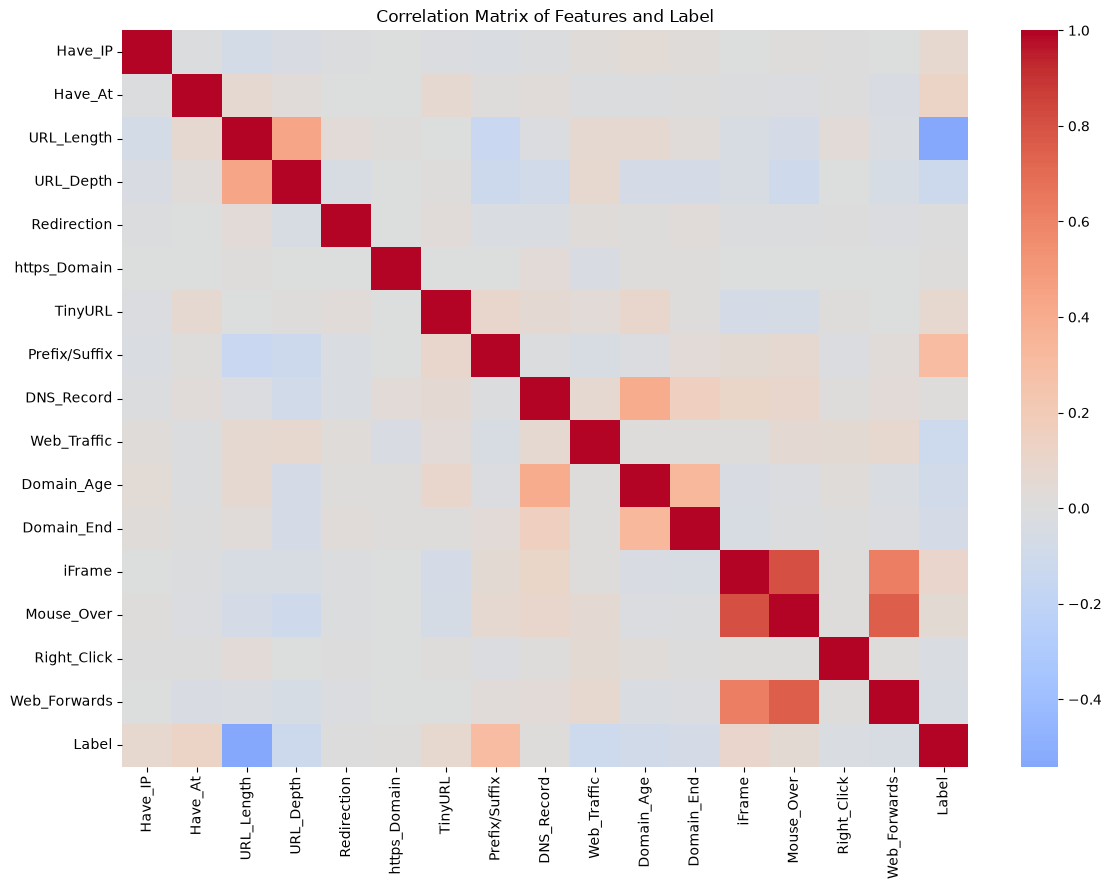

In [71]:
# Visualization of the feature correlation matrix.

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix of Features and Label")
plt.tight_layout()
plt.show()

## Correlation Methodology

I used Pearson correlation for the numerical feature correlation analysis.

Most features, as well as the `Label` column, are binary 0/1 variables. For binary variables, Pearson correlation is equivalent to the phi coefficient, so it is a reasonable first method for measuring association with the phishing label.

However, correlation should be interpreted carefully. It only captures linear association and does not prove causation. Since many features are binary or low-cardinality, the results are descriptive rather than definitive.

In this cybersecurity context, correlation helps identify which handcrafted phishing indicators are most associated with the label, but the findings should also be checked through model performance, feature importance, and error analysis.

## What I found

The correlation analysis shows that most features have weak correlation with the target label.

The strongest correlation with `Label` is `URL_Length` at -0.5413. Since `Label = 1` represents phishing, this means phishing samples tend to have lower `URL_Length` values in this dataset.

The next strongest feature is `Prefix/Suffix` at 0.3027, meaning that hyphen-based prefix/suffix patterns are more associated with phishing samples.

Other features have weaker correlations, including `URL_Depth`, `Have_At`, `Web_Traffic`, `iFrame`, and `Domain_Age`.

Several features have very weak correlation with the label, such as `Redirection`, `https_Domain`, `DNS_Record`, and `Right_Click`.

The heatmap also shows some relationships between features, especially among HTML/JavaScript-related features such as `iFrame`, `Mouse_Over`, and `Web_Forwards`.

## Consequences

The results suggest that the model may rely heavily on a small number of features, especially `URL_Length` and `Prefix/Suffix`.

From a cybersecurity perspective, this may limit robustness because attackers can adapt by changing simple URL patterns, avoiding hyphens, or using legitimate-looking domains.

The weak correlations of features such as `Redirection`, `https_Domain`, and `DNS_Record` suggest that some handcrafted phishing indicators may contribute little in this dataset.

In the modeling stage, I should check whether feature importance confirms this pattern and whether performance changes after deduplication.

# 10. Outlier and Range Analysis

I will inspect the range and distribution of numerical features, with special attention to `URL_Depth`.

I will use descriptive statistics and value counts.

Most features are binary, but `URL_Depth` is numerical and can contain larger values.

Outliers or rare extreme values may affect some machine learning models. In cybersecurity, unusually deep URLs may represent suspicious URL structures, but they may also appear in legitimate websites.

In [72]:
# Incpestion of the descriptive statistics for all numerical features.

display(df[feature_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Have_IP,10000.0,0.0055,0.073961,0.0,0.0,0.0,0.0,1.0
Have_At,10000.0,0.0226,0.148632,0.0,0.0,0.0,0.0,1.0
URL_Length,10000.0,0.7734,0.418653,0.0,1.0,1.0,1.0,1.0
URL_Depth,10000.0,3.0720,2.128631,0.0,2.0,3.0,4.0,20.0
Redirection,10000.0,0.0135,0.115408,0.0,0.0,0.0,0.0,1.0
https_Domain,10000.0,0.0002,0.014141,0.0,0.0,0.0,0.0,1.0
TinyURL,10000.0,0.0903,0.286625,0.0,0.0,0.0,0.0,1.0
Prefix/Suffix,10000.0,0.0932,0.290727,0.0,0.0,0.0,0.0,1.0
DNS_Record,10000.0,0.1008,0.301079,0.0,0.0,0.0,0.0,1.0
Web_Traffic,10000.0,0.8457,0.361254,0.0,1.0,1.0,1.0,1.0


,Label,URL_Depth,count
0,0,0,14
1,0,1,630
2,0,2,1298
3,0,3,1204
4,0,4,923
5,0,5,370
6,0,6,243
7,0,7,130
8,0,8,33
9,0,9,11


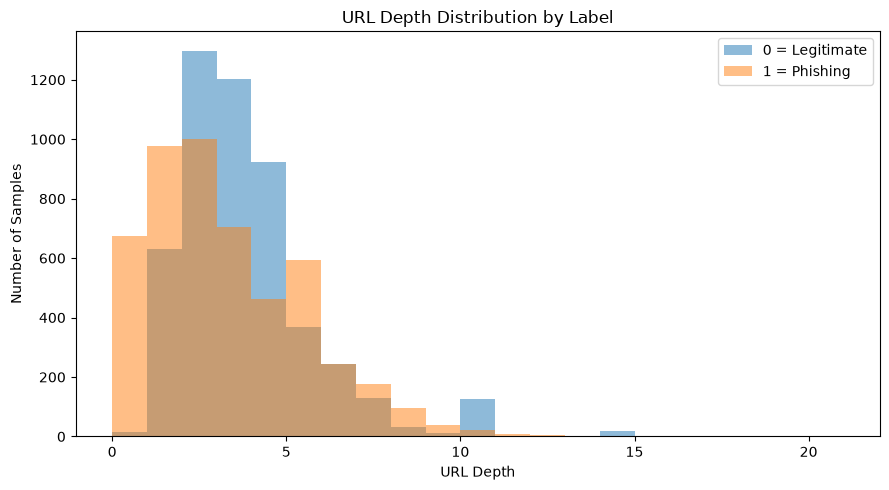

In [73]:
# Inspection of the distribution of URL_Depth by label.

url_depth_distribution = (
    df.groupby(["Label", "URL_Depth"])
      .size()
      .reset_index(name="count")
)

display(url_depth_distribution)

fig, ax = plt.subplots(figsize=(9, 5))

for label_value in sorted(df["Label"].unique()):
    subset = df[df["Label"] == label_value]
    ax.hist(
        subset["URL_Depth"],
        bins=range(int(df["URL_Depth"].min()), int(df["URL_Depth"].max()) + 2),
        alpha=0.5,
        label=f"Label {label_value}"
    )

ax.set_title("URL Depth Distribution by Label")
ax.set_xlabel("URL Depth")
ax.set_ylabel("Number of Samples")
ax.legend(["0 = Legitimate", "1 = Phishing"])

plt.tight_layout()
plt.show()

## What I found

Most features are binary and contain values between 0 and 1.

The only feature with a wider range is `URL_Depth`, which ranges from 0 to 20. Its mean is 3.072, median is 3, and 75th percentile is 4. This means most URLs have low path depth, with a few rare high-depth cases.

The histogram shows that both legitimate and phishing URLs are mostly concentrated in low URL-depth values. Legitimate samples are mainly around depths 2 to 4, while phishing samples are mostly between depths 0 to 5.

Several binary features are rare or almost constant, including:

* `https_Domain`, mean 0.0002
* `Right_Click`, mean 0.9993
* `Redirection`, mean 0.0135
* `Have_IP`, mean 0.0055

## Consequences

The dataset does not appear to contain invalid numerical ranges. Most values match the expected binary encoding, and `URL_Depth` behaves like a count-based feature.

However, features with very low variation may contribute little to classification because almost all samples have the same value.

`URL_Depth` may be useful because it has more variation, but the overlap between legitimate and phishing samples shows that it cannot reliably identify phishing on its own.

From a cybersecurity perspective, deep URL paths can appear in both phishing and legitimate websites. Therefore, `URL_Depth` should not be treated as a standalone phishing indicator.

This supports the need to evaluate feature importance and model performance instead of assuming all handcrafted features are equally useful.


# 11. Preprocessing for Modeling

I will prepare the dataset for machine learning.

I will create two versions of the data:

1. The original dataset.
2. A deduplicated dataset with fully duplicated rows removed.

For each version, I will separate the features `X` from the target label `y`.

I will remove the `Domain` column from the model input because it is a string identifier, not a numerical feature used directly by the original handcrafted feature model.

Separating features from labels is required before model training.

Removing `Domain` helps prevent the model from using domain names directly. The goal is to train on extracted phishing-related features, not memorize specific domains.

Using both the original and deduplicated datasets will allow me to compare reproduction performance with a stricter evaluation that reduces duplicate leakage.

In [74]:
# Preperation of the original and deduplicated datasets for modeling.

target_column = "Label"
identifier_column = "Domain"

# Original dataset
X_original = df.drop(columns=[target_column, identifier_column])
y_original = df[target_column]

# Deduplicated dataset
X_deduplicated = df_no_full_duplicates.drop(columns=[target_column, identifier_column])
y_deduplicated = df_no_full_duplicates[target_column]

print("Original X shape:", X_original.shape)
print("Original y shape:", y_original.shape)

print("\nDeduplicated X shape:", X_deduplicated.shape)
print("Deduplicated y shape:", y_deduplicated.shape)

print("\nFeature columns used for modeling:")
print(X_original.columns.tolist())

Original X shape: (10000, 16)
Original y shape: (10000,)

Deduplicated X shape: (4374, 16)
Deduplicated y shape: (4374,)

Feature columns used for modeling:
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']


## What I found

For the original dataset:

* `X_original`: 10,000 rows and 16 feature columns
* `y_original`: 10,000 target labels

For the deduplicated dataset:

* `X_deduplicated`: 4,374 rows and 16 feature columns
* `y_deduplicated`: 4,374 target labels

The `Domain` column was removed because it is a string identifier, not a numerical phishing feature. The `Label` column was separated as the target variable.

The final model input contains 16 handcrafted phishing-detection features, including URL structure, domain-based, and webpage-behavior features.

## Consequences

The data is now ready for machine learning.

Using the original dataset allows closer reproduction of the author’s setup, while using the deduplicated dataset allows testing whether performance remains stable after reducing duplicate leakage.

From a cybersecurity perspective, this comparison is important because phishing detection models should generalize to new websites, not repeated or memorized examples.


# 12. Train/Test Split

I will split both dataset versions into training and test sets.

I will use an 80/20 train/test split.

I will use `stratify=y` so the class distribution is preserved in both the training and test sets.

The model must be evaluated on data that was not used during training.

Using a fixed random state improves reproducibility.

Using stratification is important because class imbalance can affect the evaluation. This is especially important for the deduplicated dataset, where phishing samples are much more common than legitimate samples.

In [75]:
from sklearn.model_selection import train_test_split

# Train/test split for the original dataset
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_original
)

# Train/test split for the deduplicated dataset
X_train_deduplicated, X_test_deduplicated, y_train_deduplicated, y_test_deduplicated = train_test_split(
    X_deduplicated,
    y_deduplicated,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_deduplicated
)

print("Original dataset split:")
print("X_train:", X_train_original.shape)
print("X_test:", X_test_original.shape)
print("y_train:", y_train_original.shape)
print("y_test:", y_test_original.shape)

print("\nDeduplicated dataset split:")
print("X_train:", X_train_deduplicated.shape)
print("X_test:", X_test_deduplicated.shape)
print("y_train:", y_train_deduplicated.shape)
print("y_test:", y_test_deduplicated.shape)

Original dataset split:
X_train: (8000, 16)
X_test: (2000, 16)
y_train: (8000,)
y_test: (2000,)

Deduplicated dataset split:
X_train: (3499, 16)
X_test: (875, 16)
y_train: (3499,)
y_test: (875,)


In [76]:
# Check class distribution after the train/test split.

split_distribution = pd.DataFrame({
    "original_train": y_train_original.value_counts(normalize=True).sort_index() * 100,
    "original_test": y_test_original.value_counts(normalize=True).sort_index() * 100,
    "deduplicated_train": y_train_deduplicated.value_counts(normalize=True).sort_index() * 100,
    "deduplicated_test": y_test_deduplicated.value_counts(normalize=True).sort_index() * 100,
}).round(2)

display(split_distribution)

,original_train,original_test,deduplicated_train,deduplicated_test
Label,,,,
0,50.0,50.0,12.09,12.11
1,50.0,50.0,87.91,87.89


## What I found

Both dataset versions were successfully split into training and test sets using an 80/20 split.

For the original dataset:

* Training set: 8,000 samples
* Test set: 2,000 samples
* Class distribution remained balanced at 50% legitimate and 50% phishing

For the deduplicated dataset:

* Training set: 3,499 samples
* Test set: 875 samples
* Class distribution was preserved at around 12.1% legitimate and 87.9% phishing

This confirms that `stratify=y` worked correctly.

## Consequences

The data is now ready for model training and evaluation.

The original split supports closer reproduction of the author’s setup, while the deduplicated split provides a stricter evaluation after duplicate removal.

From an evaluation perspective, comparing these versions can show whether model performance is affected by duplicate leakage.

From a cybersecurity perspective, this matters because a phishing detector should generalize to new websites, not repeated examples.

# 13. Model Evaluation Helper Function

I will define a reusable function for evaluating classification models.

The function will calculate:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report

Using one evaluation function keeps the modeling process consistent and reduces duplicated code.

Accuracy alone is not enough, especially for cybersecurity tasks. In phishing detection, false negatives are dangerous because they mean phishing websites were classified as legitimate. False positives are also important because they mean legitimate websites were incorrectly flagged as phishing.

Therefore, I will evaluate models using multiple metrics.

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, dataset_name, y_true, y_pred):
    """
    Evaluate a classification model and return a dictionary of metrics.
    
    Parameters:
    model_name: Name of the trained model.
    dataset_name: Name of the dataset version being evaluated.
    y_true: True target labels.
    y_pred: Predicted target labels.
    
    Returns:
    A dictionary containing the main evaluation metrics.
    """
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"Model: {model_name}")
    print(f"Dataset: {dataset_name}")
    print("-" * 50)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

## Evaluation Metrics Justification

I use multiple evaluation metrics instead of relying only on accuracy.

Accuracy measures the overall percentage of correct predictions, but it can be misleading in cybersecurity because false positives and false negatives have different consequences.

Precision for phishing measures how many websites predicted as phishing were truly phishing. Low precision means more legitimate websites may be falsely flagged.

Recall for phishing measures how many actual phishing websites were detected. This is especially important because false negatives may expose users to credential theft, fraud, or malware.

F1-score balances precision and recall.

I also use balanced accuracy and macro F1-score because the deduplicated dataset is highly imbalanced. These metrics give more equal importance to both classes.

In addition, I calculate:

* F2-score, which gives more weight to recall
* MCC, which considers all four confusion matrix outcomes
* ROC-AUC, which measures class separation across thresholds

I do not rely on one metric alone because phishing detection involves a tradeoff between security and usability.

In [78]:
from sklearn.metrics import (
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score
)

def evaluate_additional_metrics(model_name, dataset_name, y_true, y_pred, y_proba=None):
    """
    Calculate additional evaluation metrics for classification models.

    Parameters:
    model_name: Name of the trained model.
    dataset_name: Name of the dataset version.
    y_true: True target labels.
    y_pred: Predicted labels.
    y_proba: Predicted probabilities for the positive class, if available.

    Returns:
    A dictionary with additional metrics.
    """
    
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
    else:
        roc_auc = None
    
    return {
        "model": model_name,
        "dataset": dataset_name,
        "f2_score": f2,
        "mcc": mcc,
        "roc_auc": roc_auc
    }

# 14. Model 1: Decision Tree Classifier

I will train a Decision Tree classifier on both dataset versions:

1. The original dataset.
2. The deduplicated dataset.

I will train the model using the training set and evaluate it on the test set.

I will use the same `random_state` for reproducibility.

Decision Tree is one of the models used in the original source, so training it helps reproduce part of the author’s experiment.

It is also an interpretable model, which makes it useful for understanding which features may influence phishing classification.

By comparing performance on the original and deduplicated datasets, I can test whether duplicate removal affects model performance.

In [79]:
from sklearn.tree import DecisionTreeClassifier

model_results = []

# Decision Tree on original dataset
decision_tree_original = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree_original.fit(X_train_original, y_train_original)

y_pred_dt_original = decision_tree_original.predict(X_test_original)

dt_original_results = evaluate_model(
    model_name="Decision Tree",
    dataset_name="Original Dataset",
    y_true=y_test_original,
    y_pred=y_pred_dt_original
)

model_results.append(dt_original_results)

Model: Decision Tree
Dataset: Original Dataset
--------------------------------------------------
Accuracy: 0.865
Precision: 0.9254
Recall: 0.794
F1-score: 0.8547

Confusion Matrix:
[[936  64]
 [206 794]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      1000
           1       0.93      0.79      0.85      1000

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.87      0.86      0.86      2000



In [80]:
# Decision Tree on deduplicated dataset
decision_tree_deduplicated = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

decision_tree_deduplicated.fit(X_train_deduplicated, y_train_deduplicated)

y_pred_dt_deduplicated = decision_tree_deduplicated.predict(X_test_deduplicated)

dt_deduplicated_results = evaluate_model(
    model_name="Decision Tree",
    dataset_name="Deduplicated Dataset",
    y_true=y_test_deduplicated,
    y_pred=y_pred_dt_deduplicated
)

model_results.append(dt_deduplicated_results)

Model: Decision Tree
Dataset: Deduplicated Dataset
--------------------------------------------------
Accuracy: 0.8811
Precision: 0.906
Recall: 0.9649
F1-score: 0.9345

Confusion Matrix:
[[ 29  77]
 [ 27 742]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.27      0.36       106
           1       0.91      0.96      0.93       769

    accuracy                           0.88       875
   macro avg       0.71      0.62      0.65       875
weighted avg       0.86      0.88      0.86       875



## What I found

The Decision Tree model was trained and evaluated on both dataset versions.

On the original dataset, it achieved:

* Accuracy: 0.865
* Precision for phishing: 0.9254
* Recall for phishing: 0.7940
* F1-score for phishing: 0.8547

The confusion matrix shows 936 true legitimate predictions, 64 false positives, 794 true phishing predictions, and 206 false negatives.

On the deduplicated dataset, it achieved:

* Accuracy: 0.8811
* Precision for phishing: 0.9060
* Recall for phishing: 0.9649
* F1-score for phishing: 0.9345

The confusion matrix shows 29 true legitimate predictions, 77 false positives, 742 true phishing predictions, and 27 false negatives.

## What it did / changed

This step trained a Decision Tree classifier on the original and deduplicated datasets. The original dataset was not modified.

The results were stored in `model_results` for later comparison.

## Consequences

On the original dataset, the model performs reasonably well, but it still misses 206 phishing websites. These false negatives are dangerous because phishing websites classified as legitimate can expose users to credential theft, fraud, or malware.

On the deduplicated dataset, phishing recall is very high, but legitimate classification is weak. Only 29 out of 106 legitimate samples were correctly classified, while 77 were falsely flagged as phishing.

This shows why accuracy alone is not enough. The model must be evaluated with precision, recall, F1-score, and confusion matrices, especially because duplication and class imbalance strongly affect interpretation.

# 15. Model 2: Random Forest Classifier

I will train a Random Forest classifier on both dataset versions:

1. The original dataset.
2. The deduplicated dataset.

I will train the model using the training set and evaluate it on the test set.

I will use 100 trees and the same `random_state` for reproducibility.

Random Forest is one of the models used in the original source.

It usually performs better and is more stable than a single Decision Tree because it combines many decision trees.

By comparing Random Forest performance on the original and deduplicated datasets, I can test whether a stronger tree-based model is also affected by duplication and class imbalance.

In [81]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest on original dataset
random_forest_original = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_original.fit(X_train_original, y_train_original)

y_pred_rf_original = random_forest_original.predict(X_test_original)

rf_original_results = evaluate_model(
    model_name="Random Forest",
    dataset_name="Original Dataset",
    y_true=y_test_original,
    y_pred=y_pred_rf_original
)

model_results.append(rf_original_results)

Model: Random Forest
Dataset: Original Dataset
--------------------------------------------------
Accuracy: 0.867
Precision: 0.9248
Recall: 0.799
F1-score: 0.8573

Confusion Matrix:
[[935  65]
 [201 799]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.88      1000
           1       0.92      0.80      0.86      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



In [82]:
# Random Forest on deduplicated dataset
random_forest_deduplicated = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_deduplicated.fit(X_train_deduplicated, y_train_deduplicated)

y_pred_rf_deduplicated = random_forest_deduplicated.predict(X_test_deduplicated)

rf_deduplicated_results = evaluate_model(
    model_name="Random Forest",
    dataset_name="Deduplicated Dataset",
    y_true=y_test_deduplicated,
    y_pred=y_pred_rf_deduplicated
)

model_results.append(rf_deduplicated_results)

Model: Random Forest
Dataset: Deduplicated Dataset
--------------------------------------------------
Accuracy: 0.8857
Precision: 0.9064
Recall: 0.9701
F1-score: 0.9372

Confusion Matrix:
[[ 29  77]
 [ 23 746]]

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.27      0.37       106
           1       0.91      0.97      0.94       769

    accuracy                           0.89       875
   macro avg       0.73      0.62      0.65       875
weighted avg       0.86      0.89      0.87       875



## What I found

The Random Forest model was trained and evaluated on both dataset versions.

On the original dataset, it achieved:

* Accuracy: 0.867
* Precision for phishing: 0.9248
* Recall for phishing: 0.7990
* F1-score for phishing: 0.8573

The confusion matrix shows 935 true legitimate predictions, 65 false positives, 799 true phishing predictions, and 201 false negatives.

On the deduplicated dataset, it achieved:

* Accuracy: 0.8857
* Precision for phishing: 0.9064
* Recall for phishing: 0.9701
* F1-score for phishing: 0.9372

The confusion matrix shows 29 true legitimate predictions, 77 false positives, 746 true phishing predictions, and 23 false negatives.

## What it did / changed

This step trained a Random Forest classifier on the original and deduplicated datasets. The original dataset was not modified.

The results were added to `model_results` for later comparison.

## Consequences

Random Forest performed slightly better than Decision Tree, but the improvement was small.

On the original dataset, it still missed 201 phishing websites, which is dangerous because false negatives may expose users to phishing attacks.

On the deduplicated dataset, phishing recall was very high, but legitimate classification was weak. Only 29 out of 106 legitimate samples were correctly classified, while 77 were falsely flagged as phishing.

This suggests that the model became biased toward predicting phishing after deduplication, partly because the deduplicated dataset is highly imbalanced.

Overall, Random Forest does not solve the main dataset-quality issues. The results are still affected by duplication, imbalance, and limited handcrafted features.

# 16. Model Results Comparison

I will compare the evaluation results of all trained models so far.

I will convert the collected `model_results` list into a dataframe and display the metrics side by side.

A comparison table makes it easier to evaluate whether a model actually improves performance.

It also helps compare performance between the original dataset and the deduplicated dataset.

In [83]:
# Summarize all model results collected so far.

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by=["dataset", "f1_score"],
    ascending=[True, False]
)

display(model_results_df)

,model,dataset,accuracy,precision,recall,f1_score
3,Random Forest,Deduplicated Dataset,0.885714,0.906440,0.970091,0.937186
1,Decision Tree,Deduplicated Dataset,0.881143,0.905983,0.964889,0.934509
2,Random Forest,Original Dataset,0.867000,0.924769,0.799000,0.857296
0,Decision Tree,Original Dataset,0.865000,0.925408,0.794000,0.854682


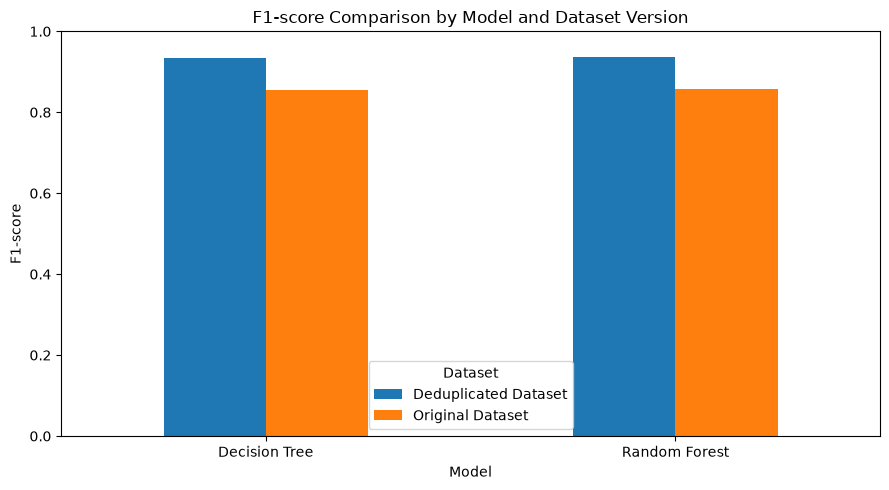

In [84]:
# Visualize model performance by dataset version.

fig, ax = plt.subplots(figsize=(9, 5))

model_results_df.pivot(
    index="model",
    columns="dataset",
    values="f1_score"
).plot(kind="bar", ax=ax)

ax.set_title("F1-score Comparison by Model and Dataset Version")
ax.set_xlabel("Model")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1)
ax.legend(title="Dataset")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## What I found

The comparison table shows that Random Forest performs slightly better than Decision Tree on both dataset versions.

On the original dataset:

* Decision Tree phishing F1-score: 0.8547
* Random Forest phishing F1-score: 0.8573

On the deduplicated dataset:

* Decision Tree phishing F1-score: 0.9345
* Random Forest phishing F1-score: 0.9372

At first glance, the deduplicated dataset appears to perform better. However, this F1-score is calculated for the phishing class only. Since the deduplicated dataset is highly imbalanced toward phishing, high phishing F1-score does not necessarily mean strong overall performance.

Earlier confusion matrices showed that both models struggled with legitimate samples in the deduplicated dataset. For example, Random Forest correctly classified only 29 out of 106 legitimate test samples.

## Consequences

Random Forest provides only a small improvement over Decision Tree.

More importantly, this comparison shows why phishing-class F1-score alone is not enough. The models detect phishing well in the deduplicated dataset, but they incorrectly flag many legitimate websites.

From a cybersecurity perspective, high phishing recall is useful, but too many false positives can cause alert fatigue, unnecessary blocking, and reduced user trust.

Therefore, balanced metrics such as balanced accuracy and macro F1-score are needed before drawing conclusions.

# 17. Balanced Evaluation Metrics

I will calculate additional evaluation metrics that are more appropriate for imbalanced data.

I will calculate:

- Balanced accuracy
- Macro F1-score
- Recall for legitimate samples
- Recall for phishing samples

The deduplicated dataset is highly imbalanced toward phishing samples.

In this case, regular accuracy and phishing F1-score may hide poor performance on the minority class, which is the legitimate class.

Balanced accuracy and macro F1-score give equal importance to both classes, so they provide a more reliable evaluation of model behavior under class imbalance.

In [85]:
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score

balanced_results = []

model_predictions = [
    {
        "model": "Decision Tree",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_dt_original
    },
    {
        "model": "Decision Tree",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_deduplicated
    },
    {
        "model": "Random Forest",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_rf_original
    },
    {
        "model": "Random Forest",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_deduplicated
    }
]

for item in model_predictions:
    balanced_results.append({
        "model": item["model"],
        "dataset": item["dataset"],
        "balanced_accuracy": balanced_accuracy_score(item["y_true"], item["y_pred"]),
        "macro_f1": f1_score(item["y_true"], item["y_pred"], average="macro", zero_division=0),
        "legitimate_recall": recall_score(item["y_true"], item["y_pred"], pos_label=0, zero_division=0),
        "phishing_recall": recall_score(item["y_true"], item["y_pred"], pos_label=1, zero_division=0)
    })

balanced_results_df = pd.DataFrame(balanced_results)

balanced_results_df = balanced_results_df.sort_values(
    by=["dataset", "macro_f1"],
    ascending=[True, False]
)

display(balanced_results_df)

,model,dataset,balanced_accuracy,macro_f1,legitimate_recall,phishing_recall
3,Random Forest,Deduplicated Dataset,0.621838,0.652137,0.273585,0.970091
1,Decision Tree,Deduplicated Dataset,0.619237,0.646267,0.273585,0.964889
2,Random Forest,Original Dataset,0.867000,0.866382,0.935000,0.799000
0,Decision Tree,Original Dataset,0.865000,0.864316,0.936000,0.794000


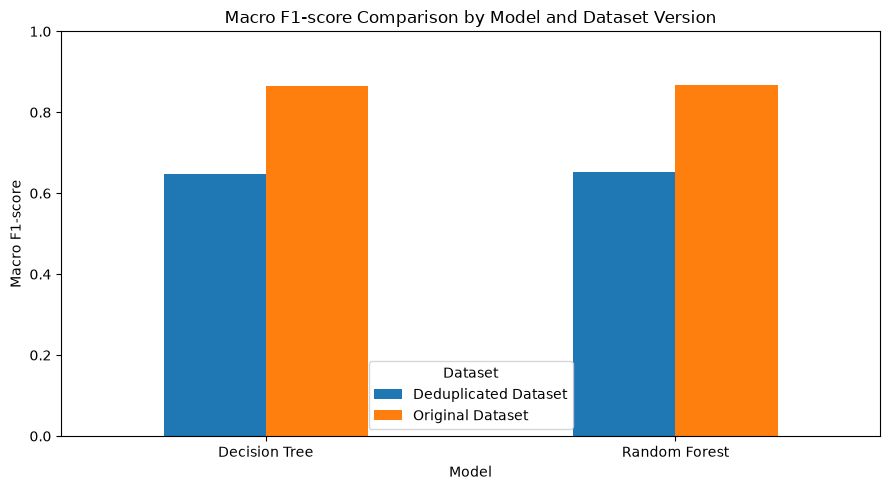

In [86]:
fig, ax = plt.subplots(figsize=(9, 5))

balanced_results_df.pivot(
    index="model",
    columns="dataset",
    values="macro_f1"
).plot(kind="bar", ax=ax)

ax.set_title("Macro F1-score Comparison by Model and Dataset Version")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1-score")
ax.set_ylim(0, 1)
ax.legend(title="Dataset")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## What I found

Balanced evaluation metrics give a clearer picture than phishing F1-score alone.

On the original dataset:

* Decision Tree macro F1-score: 0.8643
* Random Forest macro F1-score: 0.8664
* Decision Tree balanced accuracy: 0.8650
* Random Forest balanced accuracy: 0.8670

Both models perform similarly, with Random Forest slightly better.

On the deduplicated dataset:

* Decision Tree macro F1-score: 0.6463
* Random Forest macro F1-score: 0.6521
* Decision Tree balanced accuracy: 0.6192
* Random Forest balanced accuracy: 0.6218

The deduplicated results are much weaker when both classes are treated equally.

The key issue is class-specific recall. In the deduplicated dataset, legitimate recall is only 0.2736, while phishing recall is very high: 0.9649 for Decision Tree and 0.9701 for Random Forest.

## What it did / changed

This step added balanced evaluation metrics for the trained Decision Tree and Random Forest models.

## Consequences

This changes the interpretation of the previous results.

The phishing F1-score made the deduplicated dataset look strong, but macro F1-score and balanced accuracy show that overall performance is weaker.

The models are biased toward predicting phishing because the deduplicated dataset is highly imbalanced.

From a cybersecurity perspective, high phishing recall is useful, but low legitimate recall means many legitimate websites are falsely flagged. This can cause false alarms, alert fatigue, and reduced user trust.

Therefore, final evaluation should include balanced accuracy, macro F1-score, and class-specific recall, not only accuracy or phishing F1-score.


# 18. Model 3: XGBoost Classifier

I will train an XGBoost classifier on both dataset versions:

1. The original dataset.
2. The deduplicated dataset.

I will use the same train/test splits as before and evaluate the model with the same evaluation function.

XGBoost is the model that the original source reported as the best-performing model.

Training XGBoost helps evaluate whether I can reproduce the author's main performance claim and compare it against the stricter deduplicated dataset evaluation.

In [87]:
from xgboost import XGBClassifier

# XGBoost on original dataset
xgboost_original = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgboost_original.fit(X_train_original, y_train_original)

y_pred_xgb_original = xgboost_original.predict(X_test_original)

xgb_original_results = evaluate_model(
    model_name="XGBoost",
    dataset_name="Original Dataset",
    y_true=y_test_original,
    y_pred=y_pred_xgb_original
)

model_results.append(xgb_original_results)

Model: XGBoost
Dataset: Original Dataset
--------------------------------------------------
Accuracy: 0.829
Precision: 0.9621
Recall: 0.685
F1-score: 0.8002

Confusion Matrix:
[[973  27]
 [315 685]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.97      0.85      1000
           1       0.96      0.69      0.80      1000

    accuracy                           0.83      2000
   macro avg       0.86      0.83      0.83      2000
weighted avg       0.86      0.83      0.83      2000



In [88]:
# XGBoost on deduplicated dataset
xgboost_deduplicated = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)

xgboost_deduplicated.fit(X_train_deduplicated, y_train_deduplicated)

y_pred_xgb_deduplicated = xgboost_deduplicated.predict(X_test_deduplicated)

xgb_deduplicated_results = evaluate_model(
    model_name="XGBoost",
    dataset_name="Deduplicated Dataset",
    y_true=y_test_deduplicated,
    y_pred=y_pred_xgb_deduplicated
)

model_results.append(xgb_deduplicated_results)

Model: XGBoost
Dataset: Deduplicated Dataset
--------------------------------------------------
Accuracy: 0.9029
Precision: 0.9024
Recall: 0.9974
F1-score: 0.9475

Confusion Matrix:
[[ 23  83]
 [  2 767]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.22      0.35       106
           1       0.90      1.00      0.95       769

    accuracy                           0.90       875
   macro avg       0.91      0.61      0.65       875
weighted avg       0.90      0.90      0.88       875



## What I found

The XGBoost model was trained and evaluated on both dataset versions.

On the original dataset, it achieved:

* Accuracy: 0.8290
* Precision for phishing: 0.9621
* Recall for phishing: 0.6850
* F1-score for phishing: 0.8002

The confusion matrix shows 973 true legitimate predictions, 27 false positives, 685 true phishing predictions, and 315 false negatives.

On the deduplicated dataset, it achieved:

* Accuracy: 0.9029
* Precision for phishing: 0.9024
* Recall for phishing: 0.9974
* F1-score for phishing: 0.9475

The confusion matrix shows 23 true legitimate predictions, 83 false positives, 767 true phishing predictions, and 2 false negatives.

## What it did / changed

This step trained an XGBoost classifier on the original and deduplicated datasets. The original dataset was not modified.

The results were added to `model_results` for later comparison.

## Consequences

On the original dataset, XGBoost reached 82.9% accuracy, which is lower than the source’s reported XGBoost accuracy of about 86.4%. This may be due to different hyperparameters, library versions, train/test splits, or preprocessing details, but the reported result was not reproduced exactly with this simple configuration.

The main issue on the original dataset is phishing recall: XGBoost missed 315 phishing websites. These false negatives are dangerous because they may expose users to phishing attacks.

On the deduplicated dataset, XGBoost achieved very high phishing recall, but only 23 out of 106 legitimate samples were correctly classified. This means many legitimate websites were falsely flagged as phishing.

Therefore, XGBoost must be evaluated with balanced accuracy, macro F1-score, and class-specific recall, not only accuracy or phishing F1-score.

In [89]:
# I will update the balanced metrics comparison to include XGBoost.

model_predictions = [
    {
        "model": "Decision Tree",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_dt_original
    },
    {
        "model": "Decision Tree",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_deduplicated
    },
    {
        "model": "Random Forest",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_rf_original
    },
    {
        "model": "Random Forest",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_deduplicated
    },
    {
        "model": "XGBoost",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_xgb_original
    },
    {
        "model": "XGBoost",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_xgb_deduplicated
    }
]

balanced_results = []

for item in model_predictions:
    balanced_results.append({
        "model": item["model"],
        "dataset": item["dataset"],
        "balanced_accuracy": balanced_accuracy_score(item["y_true"], item["y_pred"]),
        "macro_f1": f1_score(item["y_true"], item["y_pred"], average="macro", zero_division=0),
        "legitimate_recall": recall_score(item["y_true"], item["y_pred"], pos_label=0, zero_division=0),
        "phishing_recall": recall_score(item["y_true"], item["y_pred"], pos_label=1, zero_division=0)
    })

balanced_results_df = pd.DataFrame(balanced_results)

balanced_results_df = balanced_results_df.sort_values(
    by=["dataset", "macro_f1"],
    ascending=[True, False]
)

display(balanced_results_df)

,model,dataset,balanced_accuracy,macro_f1,legitimate_recall,phishing_recall
3,Random Forest,Deduplicated Dataset,0.621838,0.652137,0.273585,0.970091
5,XGBoost,Deduplicated Dataset,0.607190,0.649322,0.216981,0.997399
1,Decision Tree,Deduplicated Dataset,0.619237,0.646267,0.273585,0.964889
2,Random Forest,Original Dataset,0.867000,0.866382,0.935000,0.799000
0,Decision Tree,Original Dataset,0.865000,0.864316,0.936000,0.794000
4,XGBoost,Original Dataset,0.829000,0.825379,0.973000,0.685000


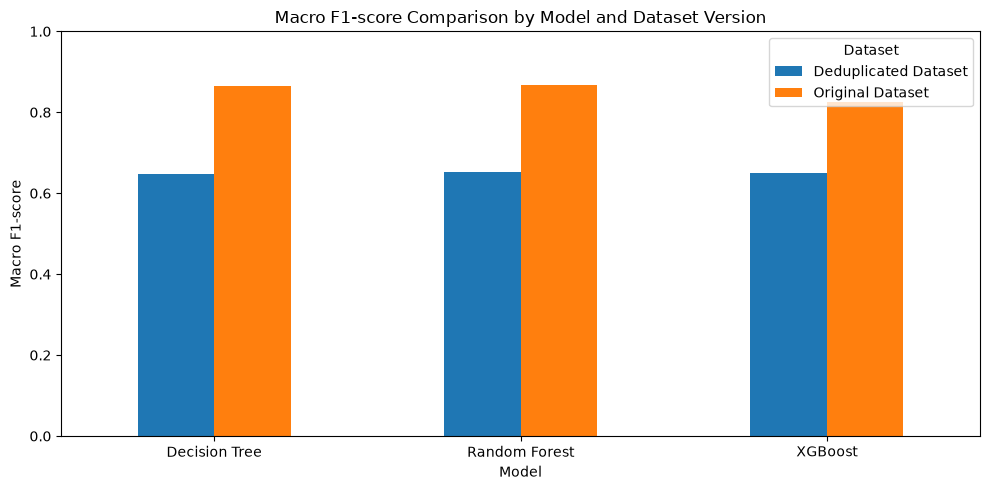

In [90]:
fig, ax = plt.subplots(figsize=(10, 5))

balanced_results_df.pivot(
    index="model",
    columns="dataset",
    values="macro_f1"
).plot(kind="bar", ax=ax)

ax.set_title("Macro F1-score Comparison by Model and Dataset Version")
ax.set_xlabel("Model")
ax.set_ylabel("Macro F1-score")
ax.set_ylim(0, 1)
ax.legend(title="Dataset")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## What I found

After adding XGBoost to the balanced evaluation comparison, the results show a clear difference between the original and deduplicated datasets.

On the original dataset:

* Random Forest had the best macro F1-score: 0.8664
* Decision Tree was close: 0.8643
* XGBoost was lower: 0.8254

On the deduplicated dataset:

* Random Forest had the best macro F1-score: 0.6521
* XGBoost: 0.6493
* Decision Tree: 0.6463

All models performed worse on the deduplicated dataset when evaluated with balanced metrics.

The class-specific recall shows the main tradeoff. On the original dataset, XGBoost had high legitimate recall, 97.3%, but lower phishing recall, 68.5%. On the deduplicated dataset, XGBoost detected 99.7% of phishing samples but correctly identified only 21.7% of legitimate samples.

## What it did / changed

This step added XGBoost to the balanced evaluation comparison across both dataset versions.

## Consequences

The results show that model performance depends strongly on the dataset version and evaluation metric.

Accuracy or phishing F1-score can make the deduplicated results look strong, but macro F1-score and balanced accuracy show that the models struggle across both classes, especially with legitimate websites.

XGBoost also did not fully reproduce the source’s reported accuracy of about 86.4%. In this setup, it achieved 82.9% accuracy on the original dataset, possibly due to different hyperparameters, split, library versions, or preprocessing.

From a cybersecurity perspective, both error types matter. Low phishing recall means missed attacks, while low legitimate recall means unnecessary blocking and alert fatigue.

Therefore, the final report should include balanced accuracy, macro F1-score, class-specific recall, and confusion matrices, not only accuracy.


# 19. Additional Robustness Experiment: Class-Weighted Models

This experiment is not part of the original source reproduction.

I include it as an additional robustness check after finding that the deduplicated dataset is highly imbalanced and that the models have very low legitimate recall.

The goal is to test whether using class weighting can reduce the bias toward the majority class and improve performance on legitimate samples.

In [91]:
# Class-weighted Decision Tree on deduplicated dataset

decision_tree_balanced = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

decision_tree_balanced.fit(X_train_deduplicated, y_train_deduplicated)

y_pred_dt_balanced = decision_tree_balanced.predict(X_test_deduplicated)

dt_balanced_results = evaluate_model(
    model_name="Decision Tree Balanced",
    dataset_name="Deduplicated Dataset",
    y_true=y_test_deduplicated,
    y_pred=y_pred_dt_balanced
)

model_results.append(dt_balanced_results)

Model: Decision Tree Balanced
Dataset: Deduplicated Dataset
--------------------------------------------------
Accuracy: 0.7726
Precision: 0.9597
Recall: 0.7737
F1-score: 0.8567

Confusion Matrix:
[[ 81  25]
 [174 595]]

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.76      0.45       106
           1       0.96      0.77      0.86       769

    accuracy                           0.77       875
   macro avg       0.64      0.77      0.65       875
weighted avg       0.88      0.77      0.81       875



In [92]:
# Class-weighted Random Forest on deduplicated dataset

random_forest_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_balanced.fit(X_train_deduplicated, y_train_deduplicated)

y_pred_rf_balanced = random_forest_balanced.predict(X_test_deduplicated)

rf_balanced_results = evaluate_model(
    model_name="Random Forest Balanced",
    dataset_name="Deduplicated Dataset",
    y_true=y_test_deduplicated,
    y_pred=y_pred_rf_balanced
)

model_results.append(rf_balanced_results)

Model: Random Forest Balanced
Dataset: Deduplicated Dataset
--------------------------------------------------
Accuracy: 0.7749
Precision: 0.9628
Recall: 0.7737
F1-score: 0.858

Confusion Matrix:
[[ 83  23]
 [174 595]]

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.78      0.46       106
           1       0.96      0.77      0.86       769

    accuracy                           0.77       875
   macro avg       0.64      0.78      0.66       875
weighted avg       0.89      0.77      0.81       875



In [93]:
# Update balanced metrics comparison including class-weighted models.

model_predictions_extended = [
    {
        "model": "Decision Tree",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_dt_original
    },
    {
        "model": "Decision Tree",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_deduplicated
    },
    {
        "model": "Random Forest",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_rf_original
    },
    {
        "model": "Random Forest",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_deduplicated
    },
    {
        "model": "XGBoost",
        "dataset": "Original Dataset",
        "y_true": y_test_original,
        "y_pred": y_pred_xgb_original
    },
    {
        "model": "XGBoost",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_xgb_deduplicated
    },
    {
        "model": "Decision Tree Balanced",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_balanced
    },
    {
        "model": "Random Forest Balanced",
        "dataset": "Deduplicated Dataset",
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_balanced
    }
]

balanced_results_extended = []

for item in model_predictions_extended:
    balanced_results_extended.append({
        "model": item["model"],
        "dataset": item["dataset"],
        "balanced_accuracy": balanced_accuracy_score(item["y_true"], item["y_pred"]),
        "macro_f1": f1_score(item["y_true"], item["y_pred"], average="macro", zero_division=0),
        "legitimate_recall": recall_score(item["y_true"], item["y_pred"], pos_label=0, zero_division=0),
        "phishing_recall": recall_score(item["y_true"], item["y_pred"], pos_label=1, zero_division=0)
    })

balanced_results_extended_df = pd.DataFrame(balanced_results_extended)

balanced_results_extended_df = balanced_results_extended_df.sort_values(
    by=["dataset", "macro_f1"],
    ascending=[True, False]
)

display(balanced_results_extended_df)

,model,dataset,balanced_accuracy,macro_f1,legitimate_recall,phishing_recall
7,Random Forest Balanced,Deduplicated Dataset,0.778375,0.657634,0.783019,0.773732
6,Decision Tree Balanced,Deduplicated Dataset,0.768942,0.652742,0.764151,0.773732
3,Random Forest,Deduplicated Dataset,0.621838,0.652137,0.273585,0.970091
5,XGBoost,Deduplicated Dataset,0.607190,0.649322,0.216981,0.997399
1,Decision Tree,Deduplicated Dataset,0.619237,0.646267,0.273585,0.964889
2,Random Forest,Original Dataset,0.867000,0.866382,0.935000,0.799000
0,Decision Tree,Original Dataset,0.865000,0.864316,0.936000,0.794000
4,XGBoost,Original Dataset,0.829000,0.825379,0.973000,0.685000


## What I found

The class-weighted models were trained on the deduplicated dataset.

For the class-weighted Decision Tree:

* Accuracy: 0.7726
* Phishing precision: 0.9597
* Phishing recall: 0.7737
* Phishing F1-score: 0.8567
* Balanced accuracy: 0.7689
* Macro F1-score: 0.6527
* Legitimate recall: 0.7642

For the class-weighted Random Forest:

* Accuracy: 0.7749
* Phishing precision: 0.9628
* Phishing recall: 0.7737
* Phishing F1-score: 0.8580
* Balanced accuracy: 0.7784
* Macro F1-score: 0.6576
* Legitimate recall: 0.7830

Compared to the non-weighted Random Forest, legitimate recall increased from 0.2736 to 0.7830, but phishing recall decreased from 0.9701 to 0.7737.

## What it did / changed

This step trained additional class-weighted models on the deduplicated dataset as a robustness experiment.

These models are not part of the original source reproduction. They were added to test whether class weighting reduces imbalance-related bias.

## Consequences

The class-weighted models show a clear tradeoff.

Without class weighting, the models strongly favored phishing predictions, giving high phishing recall but low legitimate recall.

With class weighting, the models became more balanced and identified many more legitimate websites correctly, but they missed more phishing websites.

From a cybersecurity perspective, this tradeoff matters. High phishing recall reduces missed attacks, while high false-positive rates may block legitimate websites and reduce trust.

This experiment supports the critical evaluation: dataset duplication, class imbalance, and metric choice strongly affect how model quality should be interpreted.

## 19.1 Additional Evaluation Metrics: F2, MCC, and ROC-AUC

I will calculate additional evaluation metrics for all trained models.

I will calculate:

- F2-score
- Matthews Correlation Coefficient (MCC)
- ROC-AUC

For ROC-AUC, I will use the predicted probabilities of the positive class, when available.

The assignment requires a justified evaluation methodology, not only standard accuracy reporting.

F2-score is useful for phishing detection because it gives more weight to recall. This is important because false negatives are dangerous: a phishing website classified as legitimate may expose users to credential theft, fraud, or malware.

MCC is useful because it considers all parts of the confusion matrix and is more informative under class imbalance.

ROC-AUC measures how well the model separates phishing and legitimate samples across thresholds. This helps evaluate ranking ability, not only the final class prediction.

In [94]:
# I will calculate F2-score, MCC, and ROC-AUC for all trained models.

additional_metric_inputs = [
    {
        "model": "Decision Tree",
        "dataset": "Original Dataset",
        "model_object": decision_tree_original,
        "X_test": X_test_original,
        "y_true": y_test_original,
        "y_pred": y_pred_dt_original
    },
    {
        "model": "Decision Tree",
        "dataset": "Deduplicated Dataset",
        "model_object": decision_tree_deduplicated,
        "X_test": X_test_deduplicated,
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_deduplicated
    },
    {
        "model": "Random Forest",
        "dataset": "Original Dataset",
        "model_object": random_forest_original,
        "X_test": X_test_original,
        "y_true": y_test_original,
        "y_pred": y_pred_rf_original
    },
    {
        "model": "Random Forest",
        "dataset": "Deduplicated Dataset",
        "model_object": random_forest_deduplicated,
        "X_test": X_test_deduplicated,
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_deduplicated
    },
    {
        "model": "XGBoost",
        "dataset": "Original Dataset",
        "model_object": xgboost_original,
        "X_test": X_test_original,
        "y_true": y_test_original,
        "y_pred": y_pred_xgb_original
    },
    {
        "model": "XGBoost",
        "dataset": "Deduplicated Dataset",
        "model_object": xgboost_deduplicated,
        "X_test": X_test_deduplicated,
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_xgb_deduplicated
    },
    {
        "model": "Decision Tree Balanced",
        "dataset": "Deduplicated Dataset",
        "model_object": decision_tree_balanced,
        "X_test": X_test_deduplicated,
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_dt_balanced
    },
    {
        "model": "Random Forest Balanced",
        "dataset": "Deduplicated Dataset",
        "model_object": random_forest_balanced,
        "X_test": X_test_deduplicated,
        "y_true": y_test_deduplicated,
        "y_pred": y_pred_rf_balanced
    }
]

additional_metrics_results = []

for item in additional_metric_inputs:
    y_proba = item["model_object"].predict_proba(item["X_test"])[:, 1]
    
    additional_metrics_results.append(
        evaluate_additional_metrics(
            model_name=item["model"],
            dataset_name=item["dataset"],
            y_true=item["y_true"],
            y_pred=item["y_pred"],
            y_proba=y_proba
        )
    )

additional_metrics_df = pd.DataFrame(additional_metrics_results)

additional_metrics_df = additional_metrics_df.sort_values(
    by=["dataset", "mcc"],
    ascending=[True, False]
)

display(additional_metrics_df)

,model,dataset,f2_score,mcc,roc_auc
5,XGBoost,Deduplicated Dataset,0.976821,0.419877,0.905740
7,Random Forest Balanced,Deduplicated Dataset,0.805360,0.398856,0.875531
6,Decision Tree Balanced,Deduplicated Dataset,0.804924,0.386223,0.808192
3,Random Forest,Deduplicated Dataset,0.956656,0.336300,0.869176
1,Decision Tree,Deduplicated Dataset,0.952503,0.317923,0.805285
2,Random Forest,Original Dataset,0.821340,0.740884,0.925750
0,Decision Tree,Original Dataset,0.817209,0.737473,0.916840
4,XGBoost,Original Dataset,0.726868,0.687113,0.895521


## What I found

The additional metrics give a more complete view of model performance.

On the original dataset, Random Forest had the strongest additional-metric performance:

* F2-score: 0.8213
* MCC: 0.7409
* ROC-AUC: 0.9258

Decision Tree was close behind, while XGBoost had lower F2-score and MCC on the original dataset.

On the deduplicated dataset, XGBoost had the highest F2-score and ROC-AUC:

* F2-score: 0.9768
* MCC: 0.4199
* ROC-AUC: 0.9057

However, this high F2-score must be interpreted carefully because F2 emphasizes phishing recall, and the deduplicated dataset is dominated by phishing samples.

The class-weighted models had lower F2-scores, but improved MCC compared to the non-weighted Decision Tree and Random Forest. This suggests that class weighting made predictions more balanced across both classes.

## What it did / changed

This step calculated F2-score, MCC, and ROC-AUC for all trained models.

## Consequences

These metrics confirm that conclusions depend strongly on the chosen metric.

F2-score favors models with high phishing recall, but it can hide poor legitimate recall. MCC is more balanced because it considers all confusion-matrix outcomes. ROC-AUC shows that the models can often separate the classes by score, but the final threshold still creates false-positive and false-negative tradeoffs.

From a cybersecurity perspective, there is no single best model without defining the operational goal. If the priority is catching phishing, recall and F2-score are important. If the system must avoid blocking legitimate websites, balanced accuracy, macro F1-score, MCC, and legitimate recall are also critical.

# 20. Feature Engineering and Preprocessing Decisions

The original source already performed feature engineering before publishing the final dataset. The final dataset contains handcrafted numerical features extracted from URL structure, domain information, and HTML/JavaScript behavior.

The features include binary indicators such as `Have_IP`, `Have_At`, `TinyURL`, `Prefix/Suffix`, `DNS_Record`, `iFrame`, `Mouse_Over`, and `Right_Click`, as well as the count-based feature `URL_Depth`.

No additional encoding was required because all model input features are already numerical. The only non-numerical column, `Domain`, was removed because it is an identifier string rather than a direct phishing feature.

No feature scaling was applied because the selected models are tree-based models: Decision Tree, Random Forest, and XGBoost. These models do not require standardized feature scales.

No dimensionality reduction was applied because the dataset contains only 16 model features, and interpretability is important for this project.

No feature selection was applied before training because the first goal was to reproduce the original feature setup. However, feature importance analysis was later used to evaluate which features were actually useful.

The analysis showed that some features, such as `Right_Click`, `https_Domain`, and `Redirection`, had weak correlation and low importance. This suggests that some handcrafted features may contribute little to the final models.

From a cybersecurity perspective, these features are meaningful because they represent known phishing indicators, such as suspicious URL length, hyphens in domains, URL depth, shortened URLs, and abnormal webpage behavior. However, attackers can adapt by avoiding simple suspicious patterns.

# 21. Feature Importance and Explainability

I will inspect feature importance for the trained tree-based models.

I will extract feature importance values from:

- Decision Tree
- Random Forest
- XGBoost

I will compare which features are most important in each model.

Feature importance helps explain how the models make decisions.

This is important for critical evaluation because a phishing detection model may appear accurate, but still rely on simple or fragile features.

In cybersecurity, explainability is useful because analysts need to understand whether the model is using meaningful phishing indicators or relying on dataset-specific patterns.

In [95]:
# I will collect feature importance values from the trained models on the original dataset.

feature_importance_df = pd.DataFrame({
    "feature": X_original.columns,
    "decision_tree_importance": decision_tree_original.feature_importances_,
    "random_forest_importance": random_forest_original.feature_importances_,
    "xgboost_importance": xgboost_original.feature_importances_
})

feature_importance_df["mean_importance"] = feature_importance_df[
    ["decision_tree_importance", "random_forest_importance", "xgboost_importance"]
].mean(axis=1)

feature_importance_df = feature_importance_df.sort_values(
    "mean_importance",
    ascending=False
)

display(feature_importance_df)

,feature,decision_tree_importance,random_forest_importance,xgboost_importance,mean_importance
2,URL_Length,0.480919,0.430598,0.479160,0.463559
7,Prefix/Suffix,0.135730,0.125695,0.208672,0.156699
3,URL_Depth,0.173192,0.229137,0.040994,0.147774
1,Have_At,0.041206,0.033626,0.074472,0.049768
9,Web_Traffic,0.045247,0.029434,0.035734,0.036805
12,iFrame,0.024876,0.025013,0.029385,0.026425
15,Web_Forwards,0.014997,0.021499,0.034567,0.023688
10,Domain_Age,0.019967,0.025791,0.011894,0.019217
11,Domain_End,0.018500,0.020155,0.010844,0.016500
6,TinyURL,0.013962,0.018808,0.013970,0.015580


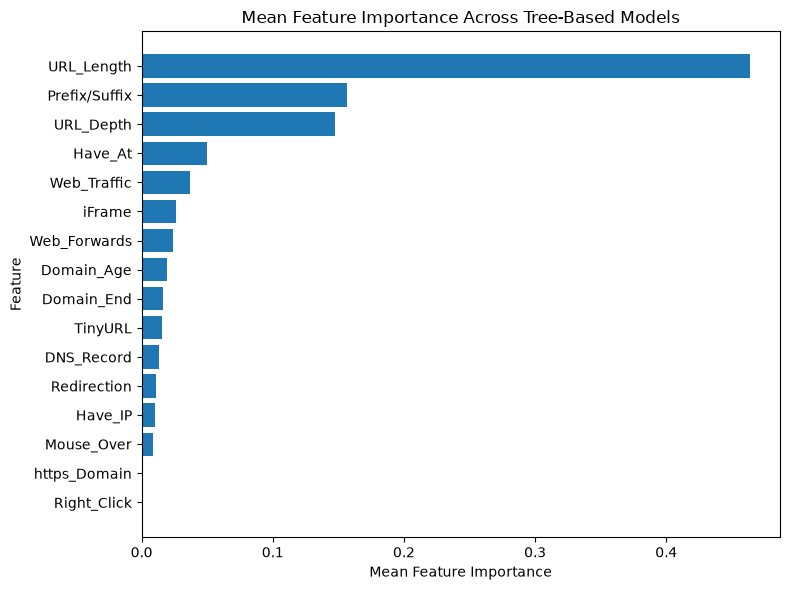

In [96]:
# I will visualize the mean feature importance across the three models.

feature_importance_plot_df = feature_importance_df.sort_values(
    "mean_importance",
    ascending=True
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    feature_importance_plot_df["feature"],
    feature_importance_plot_df["mean_importance"]
)

ax.set_title("Mean Feature Importance Across Tree-Based Models")
ax.set_xlabel("Mean Feature Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## What I found

The feature importance analysis shows that the tree-based models rely mainly on a small number of features.

The most important feature is `URL_Length`, with a mean importance of 0.4636 across the three models.

The next most important features are:

* `Prefix/Suffix`: 0.1567
* `URL_Depth`: 0.1478
* `Have_At`: 0.0498
* `Web_Traffic`: 0.0368

Several features have very low importance, including `https_Domain`, `Right_Click`, `Mouse_Over`, `Have_IP`, and `Redirection`. `Right_Click` has almost zero importance, matching the earlier EDA finding that it is almost constant.

## What it did / changed

This step extracted and compared feature importance values from Decision Tree, Random Forest, and XGBoost on the original dataset.

## Consequences

Although the dataset contains 16 features, the models rely mainly on a few URL-structure features, especially `URL_Length`, `Prefix/Suffix`, and `URL_Depth`.

From a cybersecurity perspective, this is a limitation because attackers can adapt by avoiding long URLs, hyphens, or suspicious path structures.

The low importance of some handcrafted features suggests that they contribute little to the trained models.

This supports the critical evaluation that the models may perform well on this dataset, but their real-world robustness is uncertain.

# 22. Error Analysis

I will inspect the errors made by the best-performing model on the original dataset.

I will use the Random Forest predictions on the original test set and identify:

- False positives: legitimate websites classified as phishing.
- False negatives: phishing websites classified as legitimate.

Error analysis helps understand the practical consequences of model mistakes.

In phishing detection, false negatives are especially dangerous because phishing websites are allowed through as legitimate.

False positives are also important because legitimate websites may be incorrectly blocked or flagged, which can reduce user trust and create alert fatigue.

In [97]:
# I will create an error analysis dataframe for the Random Forest model on the original dataset.

rf_original_error_df = X_test_original.copy()
rf_original_error_df["true_label"] = y_test_original.values
rf_original_error_df["predicted_label"] = y_pred_rf_original

rf_original_error_df["error_type"] = "Correct"

rf_original_error_df.loc[
    (rf_original_error_df["true_label"] == 0) & 
    (rf_original_error_df["predicted_label"] == 1),
    "error_type"
] = "False Positive"

rf_original_error_df.loc[
    (rf_original_error_df["true_label"] == 1) & 
    (rf_original_error_df["predicted_label"] == 0),
    "error_type"
] = "False Negative"

error_counts = rf_original_error_df["error_type"].value_counts()

display(error_counts)

error_type
Correct           1734
False Negative     201
False Positive      65
Name: count, dtype: int64

In [98]:
# I will inspect the average feature values for correct predictions and each error type.

error_feature_summary = (
    rf_original_error_df
    .groupby("error_type")[X_original.columns]
    .mean()
    .T
)

display(error_feature_summary)

error_type,Correct,False Negative,False Positive
Have_IP,0.004614,0.000000,0.000000
Have_At,0.028835,0.004975,0.000000
URL_Length,0.746251,1.000000,1.000000
URL_Depth,2.978662,3.348259,5.292308
Redirection,0.015571,0.009950,0.000000
https_Domain,0.000000,0.000000,0.000000
TinyURL,0.099769,0.054726,0.061538
Prefix/Suffix,0.103230,0.000000,0.015385
DNS_Record,0.102653,0.054726,0.015385
Web_Traffic,0.840254,0.895522,0.846154


## What I found

The Random Forest model on the original dataset made:

* 1,734 correct predictions
* 201 false negatives
* 65 false positives

False negatives are much more common than false positives. This is important because false negatives are phishing websites incorrectly classified as legitimate.

The feature summary suggests that many false negatives looked less suspicious according to the handcrafted features:

* `URL_Length` is 1.0 for all false negatives
* `Prefix/Suffix` is 0.0 for all false negatives
* `Have_At` is very low
* `DNS_Record`, `iFrame`, `Mouse_Over`, and `Web_Forwards` are lower than in correctly classified samples

This suggests that many missed phishing samples did not contain obvious suspicious indicators.

False positives also had `URL_Length = 1.0` and higher average `URL_Depth`, suggesting that some legitimate websites with deeper URL paths were incorrectly classified as phishing.

## What it did / changed

This step analyzed Random Forest prediction errors on the original test set and compared average feature values across correct predictions, false positives, and false negatives.

## Consequences

The error analysis shows that the model misses many phishing websites that avoid simple suspicious indicators such as `@`, hyphens, redirects, or iframe behavior.

From a cybersecurity perspective, this is serious because false negatives may expose users to credential theft, fraud, or malware.

False positives also matter because legitimate websites with suspicious-looking URL structure may be unnecessarily warned or blocked.

Overall, this supports the critical evaluation that the model relies on limited handcrafted features and may not generalize well to adaptive phishing attacks.

# 23. Experimental Results Summary

The experimental results show that model performance depends strongly on the dataset version and evaluation metric.

On the original dataset, Decision Tree and Random Forest performed similarly. Random Forest was slightly better, with accuracy 0.8670, macro F1-score 0.8664, and balanced accuracy 0.8670. Decision Tree was close, with accuracy 0.8650, macro F1-score 0.8643, and balanced accuracy 0.8650.

XGBoost did not outperform the other models in this reproduction. It achieved accuracy 0.8290, macro F1-score 0.8254, and balanced accuracy 0.8290. This does not exactly reproduce the source’s reported XGBoost accuracy of about 86.4%, possibly due to different hyperparameters, train/test split, preprocessing, or library versions.

On the deduplicated dataset, non-weighted models achieved very high phishing recall but very low legitimate recall. For example, Random Forest reached phishing recall 0.9701 but legitimate recall only 0.2736. XGBoost reached phishing recall 0.9974 but legitimate recall only 0.2170.

The class-weighted models improved legitimate recall but reduced phishing recall. For example, Random Forest Balanced reached legitimate recall 0.7830, phishing recall 0.7737, balanced accuracy 0.7784, and macro F1-score 0.6576.

The Random Forest error analysis on the original dataset showed more false negatives than false positives: 201 false negatives compared to 65 false positives. This is important because false negatives are phishing websites classified as legitimate.

Overall, the experiments show that the results are strongly affected by duplication, class imbalance, and metric choice. Therefore, the final evaluation should not rely on accuracy alone.

# 24. Critical Evaluation

The selected source presents a clear cybersecurity problem: phishing website detection using machine learning. It also provides data files, feature extraction code, model-training notebooks, and a final dataset, so it is suitable for reproduction and critical evaluation.

However, the reproduction revealed several important limitations.

### Reproducibility

The final model-training dataset is reproducible from the intermediate feature files. After renaming `Tiny_URL` to `TinyURL`, combining `3.legitimate.csv` and `4.phishing.csv` produces a dataset exactly equal to `5.urldata.csv`.

However, the full pipeline from raw URLs to extracted features is only partially reproducible. Several features depend on external and time-sensitive information, such as WHOIS records, web traffic rankings, HTTP responses, webpage source code, and redirect history. These values can change over time, especially because phishing websites are often temporary.

The random sampling process for selecting 5,000 legitimate and 5,000 phishing URLs is also not fully documented. Therefore, model training from the final CSV is reproducible, but full raw-data-to-feature reproduction is weaker.

### Dataset Quality

The dataset contains a major duplication issue. The original dataset has 10,000 rows, but after removing fully duplicated rows, only 4,374 rows remain.

Duplication is not evenly distributed. In the legitimate class, 96.42% of samples are involved in duplicated full rows, compared to 33.58% in the phishing class.

After deduplication, the dataset changes from a balanced 50/50 dataset to a highly imbalanced dataset with 12.09% legitimate samples and 87.91% phishing samples. This suggests that the original class balance is strongly affected by duplicated legitimate samples.

This matters because duplicates can cause data leakage if the same examples appear in both training and test sets, making performance look better than it would on truly unseen data.

### Feature Engineering

The dataset uses 16 numerical handcrafted features. Most are binary, and only `URL_Depth` has a wider numerical range.

The features are based on known phishing indicators, such as URL length, URL depth, `@` symbols, hyphens, shortened URLs, DNS information, and webpage behavior.

However, feature importance showed that the models rely mainly on a few URL-structure features: `URL_Length`, `Prefix/Suffix`, and `URL_Depth`. Several features, such as `Right_Click`, `https_Domain`, `Redirection`, and `Have_IP`, contribute very little.

This suggests that performance depends strongly on simple URL patterns, which may be fragile because attackers can adapt their URLs to avoid obvious suspicious indicators.

### Model Results

On the original dataset, Random Forest and Decision Tree achieved similar results. Random Forest performed slightly better, with accuracy 0.8670, macro F1-score 0.8664, and balanced accuracy 0.8670. Decision Tree was close, with accuracy 0.8650, macro F1-score 0.8643, and balanced accuracy 0.8650.

XGBoost did not outperform the other models in this reproduction. It achieved accuracy 0.8290, macro F1-score 0.8254, and balanced accuracy 0.8290. This does not exactly reproduce the source’s reported XGBoost performance of about 86.4%, possibly due to different hyperparameters, split, preprocessing, or library versions.

On the deduplicated dataset, non-weighted models achieved very high phishing recall but very low legitimate recall. Class-weighted models improved legitimate recall but reduced phishing recall, showing a tradeoff between detecting phishing attacks and avoiding false alarms.

### Error Analysis

Random Forest on the original dataset made 201 false negatives and 65 false positives.

False negatives are phishing websites classified as legitimate, which is the most dangerous error type because users may be exposed to credential theft, fraud, or malware.

The false negatives often had fewer obvious suspicious indicators, suggesting that phishing websites that look more legitimate according to the handcrafted features are harder for the model to detect.

False positives also matter because legitimate websites incorrectly classified as phishing may reduce user trust and create unnecessary blocking.

### Final Conclusion

The original source is useful and partially reproducible. The final dataset can be retraced from the intermediate feature files, and the model-training task can be reproduced from the provided CSV.

However, the critical evaluation revealed important limitations:

1. The full raw-URL-to-feature pipeline is only partially reproducible.
2. The dataset contains many duplicated rows.
3. The original class balance is strongly affected by duplicated legitimate samples.
4. The models rely heavily on a few simple URL-structure features.
5. Accuracy alone is not sufficient for evaluation.
6. Model behavior changes after deduplication and class weighting.
7. False negatives are a serious cybersecurity risk.

Overall, the experiments support the general claim that machine learning can help detect phishing websites. However, the reported performance should be interpreted carefully because duplication, feature limitations, and reproducibility issues may inflate or distort the results.

A stronger future evaluation should use a cleaner deduplicated dataset, documented random seeds, a reproducible raw-data-to-feature pipeline, time-based or domain-aware splitting, balanced metrics, and more robust features that are harder for attackers to evade.

# 25. Executive Summary

This project critically evaluated *Phishing Website Detection by Machine Learning Techniques*, which uses machine learning to classify websites as legitimate or phishing. This is an important cybersecurity problem because phishing websites can lead to credential theft, fraud, malware infection, and other user harms.

The original project uses legitimate URLs from the University of New Brunswick dataset and phishing URLs from PhishTank. The final dataset contains 10,000 samples: 5,000 legitimate and 5,000 phishing. The source extracts handcrafted features and trains several models, including Decision Tree, Random Forest, XGBoost, MLP, Autoencoder, and SVM.

In this reproduction, I inspected the dataset, analyzed the feature extraction process, checked reproducibility, performed EDA, trained Decision Tree, Random Forest, XGBoost, and class-weighted models, and evaluated the results using multiple metrics.

The reproducibility analysis showed that `5.urldata.csv` can be exactly reconstructed from `3.legitimate.csv` and `4.phishing.csv` after renaming `Tiny_URL` to `TinyURL`. However, the full raw-URL-to-feature pipeline is only partially reproducible because some features depend on external and time-sensitive sources such as WHOIS records, web traffic ranking, HTTP responses, webpage HTML, and redirect history.

The EDA revealed a major duplication issue. The original dataset has 10,000 rows, but after removing fully duplicated rows, only 4,374 rows remain. After deduplication, the class distribution changes from 50% legitimate and 50% phishing to 12.09% legitimate and 87.91% phishing. This suggests that the original balance is strongly affected by duplicated legitimate samples.

The feature analysis showed that the dataset uses 16 numerical handcrafted features, mostly binary. Feature importance showed that the models rely mainly on a few URL-structure features, especially `URL_Length`, `Prefix/Suffix`, and `URL_Depth`, while features such as `Right_Click`, `https_Domain`, and `Redirection` contributed very little.

On the original dataset, Random Forest performed best among the tested models, with 0.8670 accuracy, 0.8664 macro F1-score, and 0.8670 balanced accuracy. Decision Tree performed similarly. XGBoost achieved 0.8290 accuracy, so it did not fully reproduce the source’s reported XGBoost performance of about 86.4%.

On the deduplicated dataset, non-weighted models achieved very high phishing recall but very low legitimate recall, meaning they tended to predict phishing too often. Class-weighted models improved legitimate recall but reduced phishing recall, showing a tradeoff between detecting phishing websites and avoiding false alarms.

The error analysis showed that Random Forest on the original dataset made more false negatives than false positives. This is important because false negatives are phishing websites classified as legitimate, which is the most dangerous error type in phishing detection.

Overall, the source supports the general claim that machine learning can help detect phishing websites. However, dataset duplication, partial raw-pipeline reproducibility, class imbalance after deduplication, and reliance on simple handcrafted features limit the reliability and real-world generalizability of the results.

I recommend treating this project as a learning and baseline phishing-detection experiment, not as a production-ready system. A stronger future version should use a cleaner deduplicated dataset, documented random seeds, a reproducible raw-data-to-feature pipeline, time-based or domain-aware splits, and more robust features that are harder for attackers to evade.

# 26. Save Result Tables

The main result tables will be saved to the `report/outputs` folder.

The saved files are:

- `model_results.csv`
- `balanced_model_results.csv`
- `additional_metrics_results.csv`
- `feature_importance.csv`

In [99]:
# I will save the main result tables to the report folder.

from pathlib import Path

report_outputs_path = Path("../report/outputs")
report_outputs_path.mkdir(parents=True, exist_ok=True)

model_results_df.to_csv(report_outputs_path / "model_results.csv", index=False)
balanced_results_extended_df.to_csv(report_outputs_path / "balanced_model_results.csv", index=False)
additional_metrics_df.to_csv(report_outputs_path / "additional_metrics_results.csv", index=False)
feature_importance_df.to_csv(report_outputs_path / "feature_importance.csv", index=False)

print("Saved result tables to:", report_outputs_path)

Saved result tables to: ..\report\outputs
